# Vulcan Training 1 — Nuclear Scaling U-Net

Rebuilt from `Nuclear_Scaling_Pipeline_v9_0_1.ipynb`. Four-stage classical label
generation + U-Net training, with the scale, label, and metric defects found in
the Vulcan 1.0 post-mortem corrected.

## Changes from the v9 notebook (Vulcan 1.0)

**1. Scale constants come from an acquisition sidecar, not the config.**
`PipelineConfig` previously declared `pixel_size_um` **twice** — `0.108` then
`0.2167`. Python keeps the *last* default while holding the *first* field
position, so 0.2167 won silently and edits to the top value did nothing.
`pixel_size_um` is now a derived property of the optics
(`camera_pixel_um / (objective_mag x coupler_mag x confocal_zoom)`
= `6.5 / 40` = **0.1625 um/px**), loaded from `meta/*.json` via
`acquisition_metadata.py`. A derived quantity can no longer disagree with the
measurements it comes from.

**2. `z_step_um` corrected 1.0 -> 2.0 um** (imaging table). Every `u` in the cap
miner was previously computed at half its true value, which with
`cap_u_safe = 0.75` put the threshold out of reach of the stack entirely. Cap
mining emitted **nothing** in Vulcan 1.0 — the arm designed to fix the
cap-as-nucleus failure never ran.

**3. Labels are composed per Z plane.** v9 built one full-frame `target_hwc`
from every droplet, but each droplet's masks were segmented at its *own*
`best_z`. With 512 px patches over ~215 px droplets, neighbours are in view
constantly, so a patch imaged at z=12 could carry a neighbour's nucleus mask as
fit at z=18 — where that neighbour is a **cap**. That put genuine
cap-labelled-as-nucleus pixels into the training targets. This was not in the
original §7 cause list and is probably the dominant one.

**4. Metrics are per-sample and stateful.** v9's `_class_dice` reduced over the
batch axis. Once negatives entered the set, an empty-target batch returned 1.0
for a silent model and ~0.0 for a single false-positive pixel — so Vulcan 1.0's
`val_npc_dice` of 0.479 is not comparable to v9's 0.621. Replaced with
epoch-accumulating metrics that separate Dice-on-positives from
false-positive-rate-on-empties.

**5. Checkpoint selection targets nucleus quality**, not NPC. All three v9
callbacks monitored `val_npc_dice`, so the saved weights were the best *NPC*
model while nucleus behaviour was the actual problem.

**6. `loss_class_weights` nucleus 4.0 -> 2.5** (v10 plan item 5). Hard negatives
and a high nucleus Dice weight partly cancel; landing both at once was the point.

**7. Cap negatives are budgeted** against `max_negative_fraction` and have their
own `cap_z_floor`, since geometric labels do not depend on the detectors that
`z_floor` exists to protect.

## Deliberately NOT changed

Global-percentile normalization is implemented but **off by default**
(`normalization_mode = "per_patch"`), and 2.5D input is not implemented at all.
Both are expected to help more than anything above, but they change the
input contract and must be attributed separately. Run this notebook once as-is
to isolate the geometry and label fixes, then flip normalization for run 2.

> Vulcan 1.1 is **not** a clean ablation against 1.0 — the corrected scale moves
> `min_droplet_area_px` from 3194 to 5680, so the droplet inventory itself
> shifts. The meaningful baseline for the methods paper is 1.1, not 1.0.


In [1]:
# ============================================================
# 1. Core imports
# ============================================================
from dataclasses import dataclass, field
from pathlib import Path
import os, math, time, gc, sys, json, hashlib

from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from scipy import ndimage
from skimage import filters, morphology, measure, segmentation
from skimage.morphology import h_maxima
from skimage.feature import peak_local_max
from sklearn.cluster import DBSCAN

import tensorflow as tf
from tensorflow.keras import layers, models

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow      :", tf.__version__)
print("Num GPUs        :", len(tf.config.list_physical_devices("GPU")))
print("CPU count       :", os.cpu_count())

# Acquisition metadata: physical facts in, derived constants out.
# Path.cwd() is the kernel's launch directory, not this notebook's --
# they differ under VS Code / SLURM launchers, which is what broke this
# import. Prefer VS Code's own notebook path when available, else search
# upward from cwd for the module.
def _resolve_script_dir() -> Path:
    vsc_path = globals().get("__vsc_ipynb_file__")
    if vsc_path:
        return Path(vsc_path).resolve().parent
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / "acquisition_metadata.py").exists():
            return d
    return Path.cwd()

NOTEBOOK_DIR = _resolve_script_dir()
sys.path.insert(0, str(NOTEBOOK_DIR))
from acquisition_metadata import Acquisition, imagej_calibration


2026-07-28 13:30:46.235935: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-28 13:30:46.235986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-28 13:30:46.237133: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-28 13:30:46.244555: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-28 13:30:47.075500: W tensorflow/compiler/tf2

TensorFlow      : 2.15.1
Num GPUs        : 1
CPU count       : 128


/home/tdeibert/.conda/envs/ml_tf_2.15/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1b. Acquisition metadata

Scale constants are **derived**, never stored. `pixel_size_um` is a property of
the optical path (`6.5 um sensor pitch / (40x objective x 1x coupler x 1x CSU
zoom)`), cross-checked against the 2x3 mosaic dimensions
(`3*2048 - 2*205 = 5734 ~ 5732`; `2*2048 - 205 = 3891 ~ 3889`), which independently
identifies a 2048^2 6.5 um sensor.

`reconcile_with_tiff` compares the derived values against whatever the file
itself carries in OME/ImageJ metadata and **fails the run** on disagreement.
That check is what turns yesterday's class of error into a crash instead of a
quietly wrong dataset.


In [2]:
# ============================================================
# 1b. Acquisition metadata
# ============================================================
META_PATH = NOTEBOOK_DIR / "control_extract_1.1.json"

acq = Acquisition.load(META_PATH)          # raises on ERROR-level problems
print(f"acquisition hash: {acq.metadata_hash}")
print(f"derived pixel size: {acq.pixel_size_um:.4f} um/px "
      f"(= {acq.rig.camera_pixel_um} / {acq.rig.total_mag:g})")
print(f"z step: {acq.z_step_um} um   interval: {acq.time_interval_s} s")
for c in sorted(acq.channels, key=lambda c: c.index):
    print(f"  ch{c.index} {c.role:<9} {c.fluorophore:<20} "
          f"{c.excitation_nm:.0f} nm  {c.exposure_ms:.0f} ms")


  NOTE: 0.1625 um/px undersamples by 1.07x at 488 nm (Nyquist 0.1525). Fine if traded for speed / bleaching — recorded here so it is explicit.
acquisition hash: 9956857a8e04
derived pixel size: 0.1625 um/px (= 6.5 / 40)
z step: 2.0 um   interval: 60.0 s
  ch0 membrane  DiO                  488 nm  500 ms
  ch1 nls       SV40-NLS             561 nm  250 ms
  ch2 npc       mAb414 Alexa Fluor   640 nm  350 ms


## 2. Configuration

`PipelineConfig` no longer stores any quantity that can be derived. Scale comes
from the acquisition sidecar via `apply_acquisition`; `__post_init__` runs a
feasibility guard that refuses to build a config whose geometry cannot produce a
qualifying cap plane. The v9 duplicate-field bug is structurally impossible here
because `pixel_size_um` and `z_step_um` are set from metadata, and
`validate_geometry` cross-checks them against the stack depth.


In [3]:
# ============================================================
# 2. Configuration
# ============================================================
@dataclass
class PipelineConfig:
    # ---- Project paths ----
    data_root: Path = Path("/home/tdeibert/Data/Machine_Learning_Dev/")
    model_root: Path = None
    image_root: Path = None
    out_root:   Path = None
    image_filename: str = "control_extract_1.1.tif"

    # ---- Image metadata ----
    # SET FROM THE ACQUISITION SIDECAR. Do not hardcode: pixel_size_um is
    # camera_pixel_um / total_mag, and storing the quotient is what allowed
    # 0.108 and 0.2167 to coexist in the v9 dataclass.
    pixel_size_um: float = None
    z_step_um:     float = None
    n_channels:    int   = 3
    membrane_channel_idx: int = None   # Ch0 Membrane (dim NE probe)
    nucleus_channel_idx:  int = None   # Ch1 NLS
    npc_channel_idx:      int = None   # Ch2 NPC

    # ---- Z handling ----
    z_floor: int = 6                  # detectors unreliable below this
    inventory_ref_z: int = 15
    consensus_z_offsets: tuple = (-1, 0, 1)
    consensus_tol_frac: float = 0.10

    # ---- Early-timepoint exclusion (assembly phase) ----
    generation_min_timepoint: int = 2

    # ---- Droplet detection (h_maxima watershed; geometry-only path) ----
    npc_clip_lo_pct: float = 1.0
    npc_clip_hi_pct: float = 80.0
    droplet_blur_sigma: float = 8.0
    adaptive_block: int = 301
    adaptive_offset: float = -0.05
    closing_radius_px: int = 12
    h_depth: float = 15.0
    min_droplet_area_um2: float = 150.0
    droplet_min_circ: float = 0.70
    erosion_px: int = 10

    # ---- Per-droplet geometry ----
    geom_z_lo_offset: int = -4
    geom_z_hi_offset: int = 4
    drift_tolerance_um: float = 10.0
    dbscan_min_planes: int = 2
    ransac_tol_px: float = 4.0
    ransac_n_iter: int = 200
    ransac_min_inlier_frac: float = 0.5
    wall_n_rays: int = 180
    wall_r_lo_frac: float = 0.55
    wall_r_hi_frac: float = 1.45
    wall_smooth_sigma: float = 2.0
    wall_strength_pct: float = 35.0

    # ---- NPC puncta (RAW channel) ----
    npc_margin_px: int = 5
    npc_std_mult: float = 2.0

    # ---- NPC-shell gate (organization, not presence) ----
    gate_min_puncta: int = 8
    gate_shell_tol_px: float = 6.0
    gate_shell_min_inlier_frac: float = 0.45
    gate_membrane_nn_radius_px: int = 6
    gate_membrane_min_coloc_frac: float = 0.30
    gate_membrane_k_std: float = 1.0

    # ---- Nucleus (NLS) detection ----
    nucleus_block_size: object = None
    nucleus_min_frac: float = 0.01
    nucleus_max_frac: float = 0.50
    nucleus_min_circ: float = 0.40

    # ---- Patch extraction ----
    patch_size: int = 512
    patch_jitter_px: int = 128
    patches_per_droplet: int = 3
    min_label_fraction: float = 0.002
    timepoint_patch_weights: object = None

    # ---- Label assembly ----
    # Max |best_z - patch_z| for a droplet's masks to be trusted in a patch.
    # A droplet further away than this is a CONFLICT: its mask is invalid here,
    # but silently dropping it would relabel a real droplet as background (the
    # v9 bug (a)). So the patch is discarded instead. Watch
    # n_reject_plane_conflict; raise to 2 if it eats more than ~30% of patches.
    label_plane_tol: int = 1

    # ---- Input normalization ----
    # "per_patch"  : v9 behaviour, p1-p99.8 within each 512x512 patch.
    # "global_t"   : p1-p99.8 per (timepoint, channel) over the full frame.
    # Per-patch stretching destroys absolute intensity, so a dim cap slice and a
    # bright equatorial nucleus arrive at the model looking identical. Expected
    # to matter more than anything else here, but it changes the input contract
    # and v16 must use the SAME stats, so it is OFF for this run.
    normalization_mode: str = "per_patch"
    norm_stats: object = None          # {(t, c): (lo, hi)}, set by the driver
    norm_stats_stride: int = 4
    norm_stats_z_stride: int = 4

    # ---- Hard negatives ----
    emit_gate_failures_as_negatives: bool = True
    emit_no_nucleus_as_negatives: bool = True
    negative_patch_weight: float = 0.5
    max_negative_fraction: float = 0.35

    # ---- Cap negatives ----
    mine_cap_negatives: bool = True
    cap_u_safe: float = 0.60           # physical floor is r/R ~ 0.53
    cap_z_floor: int = 3               # geometric labels, not detector output
    cap_patches_per_droplet: int = 1

    # ---- Parallel ----
    max_parallel_workers: int = 10

    # ---- Model / training ----
    model_name: str = "Vulcan_1.1"
    num_classes: int = 4
    batch_size: int = 2
    epochs: int = 50
    learning_rate: float = 1e-4
    validation_fraction: float = 0.20
    seed: int = 42
    use_augmentation: bool = True
    loss_class_weights: tuple = (0.3, 0.5, 5.0, 2.5)   # bg, droplet, npc, nucleus
    checkpoint_monitor: str = "val_nucleus_quality"
    val_timepoints: object = None

    def __post_init__(self):
        if self.model_root is None: self.model_root = self.data_root / "Models"
        if self.image_root is None: self.image_root = self.data_root / "Images"
        if self.out_root   is None: self.out_root   = self.data_root / "Outputs"

    # ---- Derived paths ----
    @property
    def image_file(self):      return self.image_root / self.image_filename
    @property
    def training_root(self):   return self.out_root / f"training_patches_{self.model_name}"
    @property
    def image_patch_dir(self): return self.training_root / "images"
    @property
    def label_patch_dir(self): return self.training_root / "labels"
    @property
    def qc_dir(self):          return self.out_root / f"qc_{self.model_name}"
    @property
    def best_model_path(self): return self.model_root / f"{self.model_name}_best.keras"
    @property
    def final_model_path(self):return self.model_root / f"{self.model_name}_final.keras"
    @property
    def norm_stats_path(self): return self.qc_dir / f"norm_stats_{self.model_name}.json"

    def min_droplet_area_px(self):
        return self.min_droplet_area_um2 / (self.pixel_size_um ** 2)

    def patches_for_timepoint(self, t):
        if self.timepoint_patch_weights is None:
            return self.patches_per_droplet
        w = list(self.timepoint_patch_weights)
        wt = w[t] if t < len(w) else 1.0
        return max(1, round(self.patches_per_droplet * wt))


def apply_acquisition(cfg, acq):
    """Push metadata into the config. The ONLY place scale enters the pipeline."""
    cfg.pixel_size_um = acq.pixel_size_um
    cfg.z_step_um = acq.z_step_um
    cfg.membrane_channel_idx = acq.role_index("membrane")
    cfg.nucleus_channel_idx  = acq.role_index("nls")
    cfg.npc_channel_idx      = acq.role_index("npc")
    cfg.n_channels = len(acq.channels)
    cfg.image_filename = acq.image_filename
    return cfg


def validate_geometry(cfg, droplet_diam_px=215.0, n_z=20):
    """Refuse a config whose geometry cannot produce a qualifying cap plane.

    This is the guard for the Vulcan 1.0 failure: a scale constant that is
    self-consistent in isolation but silently makes an entire arm of the
    pipeline a no-op.
    """
    if cfg.pixel_size_um is None or cfg.z_step_um is None:
        raise ValueError("scale not set — call apply_acquisition(cfg, acq) first")

    R_um = (droplet_diam_px / 2.0) * cfg.pixel_size_um
    u_max = (n_z / 2.0) * cfg.z_step_um / R_um

    if u_max <= 0.53:
        raise ValueError(
            f"z-stack cannot reach a cap: max u={u_max:.2f} <= r/R~0.53 "
            f"(pixel_size_um={cfg.pixel_size_um}, z_step_um={cfg.z_step_um}). "
            f"One of them is wrong.")
    if cfg.mine_cap_negatives and u_max <= cfg.cap_u_safe:
        raise ValueError(
            f"cap mining infeasible: max u={u_max:.2f} <= cap_u_safe="
            f"{cfg.cap_u_safe}. Lower cap_u_safe (floor 0.53) or recheck scale.")
    if cfg.cap_z_floor > cfg.z_floor:
        raise ValueError("cap_z_floor above z_floor defeats its purpose.")

    k = cfg.cap_u_safe * R_um / cfg.z_step_um
    print(f"geometry OK: R={R_um:.1f} um (droplet {2*R_um:.1f} um), "
          f"stack span {n_z*cfg.z_step_um:.0f} um, max u={u_max:.2f}")
    print(f"  cap planes must be >{k:.1f} planes from z_eq")
    return True


cfg = PipelineConfig()
apply_acquisition(cfg, acq)

cfg.timepoint_patch_weights = (0.25, 0.25, 0.5, 0.5, 1.0, 2.0, 3.0, 4.0, 4.0, 5.0)
cfg.val_timepoints = [2, 5, 8]
cfg.max_parallel_workers = int(os.environ.get("SLURM_CPUS_PER_TASK", 10))

validate_geometry(cfg, n_z=acq.n_z or 20)

# Cross-check the derived scale against the file's own embedded metadata.
# Collect everything first so a single failure does not hide the rest — the
# pixel-size check runs before the dimension checks, and raising on the first
# error meant the dimension comparisons never executed.
_problems = acq.reconcile_with_tiff(cfg.image_file)
for msg in _problems:
    print(" ", msg)
_errors = [m for m in _problems if m.startswith("ERROR")]
if _errors:
    raise ValueError(f"{len(_errors)} reconciliation error(s); see above")

for p in [cfg.data_root, cfg.model_root, cfg.image_root, cfg.out_root,
          cfg.training_root, cfg.image_patch_dir, cfg.label_patch_dir, cfg.qc_dir]:
    p.mkdir(parents=True, exist_ok=True)

# Channel / class constants
MEM_CH, NUC_CH, NPC_CH = cfg.membrane_channel_idx, cfg.nucleus_channel_idx, cfg.npc_channel_idx
PIXEL_SIZE_UM = cfg.pixel_size_um
PATCH_SIZE    = cfg.patch_size
NUM_CHANNELS  = cfg.n_channels
NUM_CLASSES   = cfg.num_classes
CLASS_BACKGROUND, CLASS_DROPLET, CLASS_NPC, CLASS_NUCLEUS = 0, 1, 2, 3
CLASS_NAMES = ["Background", "Droplet", "NPC", "Nucleus"]

print("\nimage_file              :", cfg.image_file)
print("training_root           :", cfg.training_root)
print("pixel_size_um           :", cfg.pixel_size_um)
print("z_step_um               :", cfg.z_step_um)
print("min_droplet_area_px     :", round(cfg.min_droplet_area_px()))
print("normalization_mode      :", cfg.normalization_mode)
print("loss_class_weights      :", cfg.loss_class_weights)
print("checkpoint_monitor      :", cfg.checkpoint_monitor)
print("patches/timepoint t0-9  :", [cfg.patches_for_timepoint(t) for t in range(10)])


geometry OK: R=17.5 um (droplet 34.9 um), stack span 40 um, max u=1.14
  cap planes must be >5.2 planes from z_eq
  NOTE: control_extract_1.1.tif carries no spatial calibration (ImageJ metadata has no `unit` field), so the derived 0.1625 um/px cannot be cross-checked against it. Verified instead by the mosaic arithmetic.
  NOTE: no z-step in file metadata either.

image_file              : /home/tdeibert/Data/Machine_Learning_Dev/Images/control_extract_1.1.tif
training_root           : /home/tdeibert/Data/Machine_Learning_Dev/Outputs/training_patches_Vulcan_1.1
pixel_size_um           : 0.1625
z_step_um               : 2.0
min_droplet_area_px     : 5680
normalization_mode      : per_patch
loss_class_weights      : (0.3, 0.5, 5.0, 2.5)
checkpoint_monitor      : val_nucleus_quality
patches/timepoint t0-9  : [1, 1, 2, 2, 3, 6, 9, 12, 12, 15]


## 3. Histogram-safe IO

`extract_plane` always returns a fresh float32 copy so nothing downstream can
mutate the source hyperstack or another class's view. `clip_histogram` is used
**only** on the droplet-detection path.

In [5]:
# ============================================================
# 3. Histogram-safe channel access
# ============================================================
def load_memmap_tiff(path):
    """Open the hyperstack as a read-only memmap (T, Z, C, Y, X)."""
    return tiff.memmap(str(path))

def extract_plane(hyperstack, t, z, c):
    """Single 2D plane as a fresh float32 COPY (callers may clip/blur freely)."""
    return np.asarray(hyperstack[t, z, c], dtype=np.float32).copy()

def clip_histogram(img, lo_pct, hi_pct):
    """Percentile-clip + 0-1 normalise a COPY. Droplet-detection path ONLY."""
    work = img.astype(np.float32, copy=True)
    lo, hi = np.percentile(work, [lo_pct, hi_pct])
    work = np.clip(work, lo, hi)
    rng = hi - lo
    return np.zeros_like(work) if rng <= 0 else (work - lo) / rng

def _circularity(region):
    p = region.perimeter
    return 0.0 if p <= 0 else float(4.0 * np.pi * region.area / (p * p))

def normalize_channel(ch2d, stats=None):
    """0-1 percentile normalise for model input patches.

    stats=None  -> per-patch p1-p99.8 (v9 behaviour).
    stats=(lo,hi) -> fixed range, so relative intensity survives across Z.

    Per-patch stretching is why a cap slice and an equatorial nucleus arrive at
    the model looking the same: both get their own dynamic range expanded to
    [0,1]. The shape cue alone cannot separate two round filled discs.
    """
    ch = ch2d.astype(np.float32)
    if stats is None:
        lo, hi = np.percentile(ch, [1, 99.8])
    else:
        lo, hi = stats
    if hi <= lo:
        return np.zeros_like(ch)
    return np.clip((ch - lo) / (hi - lo), 0, 1)


def compute_global_norm_stats(image_path, cfg=cfg):
    """p1/p99.8 per (timepoint, channel) over the full frame.

    Pooled ACROSS Z on purpose — normalising per plane would reintroduce the
    exact blindness this is meant to remove. Subsampled for speed; percentiles
    are insensitive to it at these pixel counts.
    """
    hs = tiff.memmap(str(image_path))
    n_t, n_z, n_c, H, W = hs.shape
    sy = sx = cfg.norm_stats_stride
    zs = list(range(cfg.z_floor, n_z, cfg.norm_stats_z_stride)) or [n_z // 2]
    stats = {}
    for t in range(n_t):
        for c in range(n_c):
            pool = np.concatenate([
                np.asarray(hs[t, z, c, ::sy, ::sx], dtype=np.float32).ravel()
                for z in zs])
            lo, hi = np.percentile(pool, [1, 99.8])
            stats[(t, c)] = (float(lo), float(hi))
    del hs
    return stats


def save_norm_stats(stats, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(
        {f"{t}_{c}": v for (t, c), v in stats.items()}, indent=2))


def load_norm_stats(path):
    """v16 inference MUST load these rather than recomputing."""
    raw = json.loads(Path(path).read_text())
    return {tuple(int(x) for x in k.split("_")): tuple(v) for k, v in raw.items()}


def _stats_for(cfg, t, c):
    if cfg.normalization_mode == "per_patch" or not cfg.norm_stats:
        return None
    return cfg.norm_stats.get((t, c))

def z_in_focus_range(z, n_z, cfg=cfg):
    """Exclude coverslip-artifact planes below the floor."""
    return cfg.z_floor <= z < n_z


## 4. Droplet geometry — shared primitives

This section is the validated geometry core. In the eventual package refactor it
becomes `droplet_geometry.py`, imported by both label generation and the
downstream ER radial analysis.

- `detect_droplets_npc_watershed` — h_maxima seeding + vacuole closing (Stage 1).
- `fit_circle_ransac` — **shared** RANSAC primitive, used for both droplet-wall
  fitting (Stage 3) and NPC-shell gating (Stage 2).
- `detect_droplets_multiplane` / `link_droplets_dbscan` — drift-tolerant linking.
- `extract_wall_points_radial` / `fit_droplet_circle_at_plane` — per-plane extent.

In [6]:
# ============================================================
# 4a. Stage-1 detector: h_maxima watershed (geometry-only)
# ============================================================
def detect_droplets_npc_watershed(npc_plane, cfg=cfg):
    """
    Detect droplets from one NPC plane. Geometry-only: pixel values are NOT
    preserved. h_maxima seeding (depth-based) keeps one seed per droplet while
    preserving genuinely-touching droplets; closing bridges dark vacuoles.

    Returns list of dicts: {label, mask(eroded bool), bbox, centroid, area, circ}
    """
    img_norm = clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct)
    img_blur = filters.gaussian(img_norm, sigma=cfg.droplet_blur_sigma)

    local_thresh = filters.threshold_local(img_blur, block_size=cfg.adaptive_block,
                                            offset=cfg.adaptive_offset)
    fg = img_blur > local_thresh
    fg = morphology.binary_closing(fg, morphology.disk(cfg.closing_radius_px))  # bridge vacuole
    fg = ndimage.binary_fill_holes(fg)
    min_area = int(cfg.min_droplet_area_px())
    fg = morphology.remove_small_objects(fg, min_size=min_area)

    dist = ndimage.distance_transform_edt(fg)
    maxima = h_maxima(dist, cfg.h_depth)              # depth-based seeds
    markers = measure.label(maxima)
    if markers.max() == 0:
        return []

    ws = segmentation.watershed(-dist, markers, mask=fg)

    droplets = []
    selem = morphology.disk(cfg.erosion_px)
    for region in measure.regionprops(ws):
        if region.area < min_area:
            continue
        circ = _circularity(region)
        if circ < cfg.droplet_min_circ:
            continue
        region_mask = ndimage.binary_fill_holes(ws == region.label)
        eroded = morphology.binary_erosion(region_mask, selem)
        if not eroded.any():
            continue
        ys, xs = np.where(eroded)
        droplets.append({
            "label":    int(region.label),
            "mask":     eroded,
            "bbox":     (int(ys.min()), int(xs.min()), int(ys.max())+1, int(xs.max())+1),
            "centroid": (float(ys.mean()), float(xs.mean())),
            "area":     int(eroded.sum()),
            "circ":     round(circ, 3),
        })
    return droplets


In [7]:
# ============================================================
# 4b. Shared RANSAC circle primitive
#     Used for BOTH droplet-wall fitting and NPC-shell gating.
# ============================================================
def _circle_from_3(p1, p2, p3):
    ax, ay = p1; bx, by = p2; cx, cy = p3
    d = 2.0 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-9:
        return None
    a2, b2, c2 = ax*ax+ay*ay, bx*bx+by*by, cx*cx+cy*cy
    ux = (a2*(by-cy) + b2*(cy-ay) + c2*(ay-by)) / d
    uy = (a2*(cx-bx) + b2*(ax-cx) + c2*(bx-ax)) / d
    return ux, uy, float(np.hypot(ux-ax, uy-ay))

def _fit_circle_kasa(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.c_[x, y, np.ones(len(x))]
    b = x*x + y*y
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = sol[0]/2.0, sol[1]/2.0
    r = np.sqrt(max(sol[2] + cx*cx + cy*cy, 0.0))
    return cx, cy, r

def fit_circle_ransac(pts, tol_px=4.0, n_iter=200, min_inlier_frac=0.5, rng=None):
    """
    RANSAC circle fit to Nx2 (x, y). Returns (cx, cy, r, inlier_mask) or None.
    Tolerant of missing arcs (touching neighbours) and stray points.
    Shared primitive: droplet wall (many points) and NPC shell (fewer points).
    """
    rng = rng or np.random.default_rng(0)
    n = len(pts)
    if n < 3:
        return None
    best_inliers, best_circle = None, None
    for _ in range(n_iter):
        idx = rng.choice(n, 3, replace=False)
        circ = _circle_from_3(pts[idx[0]], pts[idx[1]], pts[idx[2]])
        if circ is None:
            continue
        cx, cy, r = circ
        resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
        inliers = resid < tol_px
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers, best_circle = inliers, circ
    if best_inliers is None or best_inliers.sum() < max(3, int(min_inlier_frac*n)):
        return None
    cx, cy, r = _fit_circle_kasa(pts[best_inliers])      # refit on inliers
    resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
    return cx, cy, r, resid < tol_px


In [8]:
# ============================================================
# 4c. Multi-plane detection + DBSCAN center-linking (drift-tolerant)
# ============================================================
def detect_droplets_multiplane(hyperstack, t, z_range, cfg=cfg):
    """Run the watershed detector on each z; return flat list of detections."""
    dets = []
    for z in z_range:
        npc = extract_plane(hyperstack, t, z, cfg.npc_channel_idx)
        for d in detect_droplets_npc_watershed(npc, cfg=cfg):
            cy, cx = d["centroid"]
            dets.append({"z": int(z), "x": float(cx), "y": float(cy),
                         "r": float(np.sqrt(d["area"]/np.pi)),
                         "area": int(d["area"]), "circ": float(d["circ"])})
    return dets

def link_droplets_dbscan(dets, cfg=cfg):
    """
    Cluster detections by (x, y) across z with DBSCAN. eps = drift tolerance
    (um) / pixel size. Each cluster is one physical droplet tracked through z.
    Returns list of tracks (each a list of detection dicts sorted by z).
    """
    if not dets:
        return []
    xy = np.array([[d["x"], d["y"]] for d in dets])
    eps_px = cfg.drift_tolerance_um / cfg.pixel_size_um
    labels = DBSCAN(eps=eps_px, min_samples=cfg.dbscan_min_planes).fit_predict(xy)
    tracks = []
    for lab in sorted(set(labels)):
        if lab == -1:
            continue
        members = [dets[i] for i in range(len(dets)) if labels[i] == lab]
        members.sort(key=lambda d: d["z"])
        tracks.append(members)
    return tracks


In [9]:
# ============================================================
# 4d. Per-plane wall extraction + circle fit at a target plane
# ============================================================
def extract_wall_points_radial(npc_plane, center_xy, r_prior, cfg=cfg):
    """
    Cast rays from center; wall = steepest interior->exterior intensity fall in
    [r_lo, r_hi]*r_prior. Rays through touching neighbours give weak edges and
    are dropped by the strength percentile. Returns Nx2 (x, y). Geometry-only.
    """
    cx, cy = center_xy
    H, W = npc_plane.shape
    img = filters.gaussian(clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct),
                           cfg.wall_smooth_sigma)
    radii = np.arange(r_prior*cfg.wall_r_lo_frac, r_prior*cfg.wall_r_hi_frac, 1.0)
    pts, strengths = [], []
    for theta in np.linspace(0, 2*np.pi, cfg.wall_n_rays, endpoint=False):
        dx, dy = np.cos(theta), np.sin(theta)
        xs, ys = cx + radii*dx, cy + radii*dy
        ok = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        if ok.sum() < 5:
            continue
        prof = ndimage.map_coordinates(img, [ys[ok], xs[ok]], order=1)
        grad = np.gradient(prof)
        j = int(np.argmin(grad))                  # steepest fall = wall
        edge_r = radii[ok][j]
        pts.append((cx + edge_r*dx, cy + edge_r*dy))
        strengths.append(-grad[j])
    if not pts:
        return np.empty((0, 2))
    pts, strengths = np.array(pts), np.array(strengths)
    keep = strengths >= np.percentile(strengths, cfg.wall_strength_pct)
    return pts[keep]

def fit_droplet_circle_at_plane(hyperstack, t, z_target, seed_center_xy, r_prior, cfg=cfg):
    """
    Recover the droplet circle at z_target: wall points seeded from a (linked)
    center, then RANSAC. Returns (cx, cy, r, wall_pts, inlier_mask) or None.
    """
    npc = extract_plane(hyperstack, t, z_target, cfg.npc_channel_idx)
    wall = extract_wall_points_radial(npc, seed_center_xy, r_prior, cfg=cfg)
    if len(wall) < 3:
        return None
    fit = fit_circle_ransac(wall, tol_px=cfg.ransac_tol_px, n_iter=cfg.ransac_n_iter,
                            min_inlier_frac=cfg.ransac_min_inlier_frac)
    if fit is None:
        return None
    cx, cy, r, inliers = fit
    return cx, cy, r, wall, inliers

def circle_to_mask(cx, cy, r, shape):
    """Rasterise a filled circle to a boolean mask of the given (H, W) shape."""
    H, W = shape
    yy, xx = np.ogrid[:H, :W]
    return (xx - cx)**2 + (yy - cy)**2 <= r*r


## 5. Nucleus (NLS) and NPC puncta detection

Ported unchanged from the validated methodology. The threshold-sweep confirmed
the NLS detector is healthy when given a correct droplet interior. NPC puncta
detection reads the **RAW** NPC plane (channel-separation invariant).

In [10]:
# ============================================================
# 5a. Nucleus (NLS) detection — adaptive with per-droplet Otsu fallback
# ============================================================
def detect_nucleus_adaptive(nls_crop, droplet_mask_crop, cfg=cfg):
    """
    Detect nucleus interior from the NLS crop of one droplet.
    Primary: adaptive local threshold within the droplet.
    Fallback: per-droplet Otsu on interior values.
    No nucleus hallucinated -> returns (empty, 'none') for early/empty cases.
    Returns (mask bool, method in {'adaptive','otsu','none'}).
    """
    nls = nls_crop.astype(np.float32, copy=True)
    droplet_area = int(droplet_mask_crop.sum())
    empty = np.zeros_like(droplet_mask_crop, dtype=bool)
    if droplet_area == 0:
        return empty, "none"

    if cfg.nucleus_block_size is None:
        diameter = 2.0 * np.sqrt(droplet_area / np.pi)
        bs = max(3, int(diameter / 3))
        bs = bs + 1 if bs % 2 == 0 else bs
    else:
        bs = cfg.nucleus_block_size

    def _clean_and_gate(mask):
        mask = mask & droplet_mask_crop
        mask = morphology.remove_small_objects(mask, min_size=64)
        mask = ndimage.binary_fill_holes(mask)
        frac = mask.sum() / droplet_area
        if not (cfg.nucleus_min_frac <= frac <= cfg.nucleus_max_frac):
            return None
        lbl = measure.label(mask)
        props = measure.regionprops(lbl)
        if not props:
            return None
        biggest = max(props, key=lambda r: r.area)
        if _circularity(biggest) < cfg.nucleus_min_circ:
            return None
        return lbl == biggest.label

    try:
        local_t = filters.threshold_local(nls, block_size=bs)
        cand = _clean_and_gate(nls > local_t)
        if cand is not None:
            return cand, "adaptive"
    except Exception:
        pass
    try:
        vals = nls[droplet_mask_crop]
        if vals.size and vals.max() > vals.min():
            cand = _clean_and_gate(nls > filters.threshold_otsu(vals))
            if cand is not None:
                return cand, "otsu"
    except Exception:
        pass
    return empty, "none"


In [11]:
# ============================================================
# 5b. NPC puncta detection — RAW channel, nucleus-boundary anchored
# ============================================================
def detect_npc_puncta(npc_crop_raw, nucleus_mask_crop, droplet_mask_crop, cfg=cfg):
    """
    NPC puncta in an annular zone straddling the nucleus edge.
    npc_crop_raw MUST be the RAW NPC plane (channel-separation invariant) -
    the clipped droplet-detection array has the puncta signal removed.
    threshold = mean + k*std of RAW NPC over the droplet interior.
    """
    if nucleus_mask_crop.sum() == 0:
        return np.zeros_like(nucleus_mask_crop, dtype=bool)
    npc = npc_crop_raw.astype(np.float32, copy=True)
    selem = morphology.disk(cfg.npc_margin_px)
    outer = morphology.binary_dilation(nucleus_mask_crop, selem)
    inner = morphology.binary_erosion(nucleus_mask_crop, selem)
    zone = outer & ~inner
    interior_vals = npc[droplet_mask_crop]
    if interior_vals.size == 0:
        return np.zeros_like(nucleus_mask_crop, dtype=bool)
    thresh = interior_vals.mean() + cfg.npc_std_mult * interior_vals.std()
    return (npc > thresh) & zone


## 6. Stage-2 gate — NPC-shell organization + Membrane co-localization

The gate tests **organization, not presence**. A presence-only check passes
cap artifacts and antibody clumps. Two complementary geometric tests:

- **Shell organization (primary):** the shared `fit_circle_ransac` primitive is
  run on the NPC-punctum point cloud. A coherent low-residual circle of sensible
  radius = nuclear envelope; no consensus = scattered cap/clump signal.
- **Membrane co-localization (secondary):** true NPC sits on the NE, which the
  dim Membrane channel also marks. Each punctum needs a membrane neighbor within
  R; a minimum fraction must be supported.

Both must pass. Early timepoints (t < `generation_min_timepoint`) never reach
the gate — they are excluded at generation.

In [12]:
# ============================================================
# 6. NPC-shell gate (organization, not presence)
# ============================================================
def _punctum_centroids(npc_puncta_mask):
    """Centroids (x, y) of connected NPC puncta in crop coordinates."""
    lbl = measure.label(npc_puncta_mask)
    return np.array([[r.centroid[1], r.centroid[0]]
                     for r in measure.regionprops(lbl)], dtype=float)

def gate_npc_shell(npc_puncta_mask, cfg=cfg):
    """
    Shell-organization test. Returns (passed: bool, info: dict).
    Puncta must admit a coherent RANSAC circle fit (envelope), not scatter.
    """
    cents = _punctum_centroids(npc_puncta_mask)
    info = {"n_puncta": len(cents), "shell_r": None, "shell_inliers": 0}
    if len(cents) < cfg.gate_min_puncta:
        return False, info
    fit = fit_circle_ransac(cents, tol_px=cfg.gate_shell_tol_px,
                            n_iter=cfg.ransac_n_iter,
                            min_inlier_frac=cfg.gate_shell_min_inlier_frac)
    if fit is None:
        return False, info
    cx, cy, r, inliers = fit
    info["shell_r"], info["shell_inliers"] = float(r), int(inliers.sum())
    passed = inliers.sum() >= max(3, int(cfg.gate_shell_min_inlier_frac * len(cents)))
    return passed, info

def gate_membrane_coloc(npc_puncta_mask, mem_crop_raw, droplet_mask_crop, cfg=cfg):
    """
    Membrane co-localization test. Returns (passed: bool, info: dict).
    Each NPC punctum must have membrane signal (mean + k*std, dim probe) within
    gate_membrane_nn_radius_px; a minimum fraction of puncta must be supported.
    """
    cents = _punctum_centroids(npc_puncta_mask)
    info = {"coloc_frac": 0.0}
    if len(cents) == 0:
        return False, info
    mem = mem_crop_raw.astype(np.float32, copy=True)
    interior = mem[droplet_mask_crop]
    if interior.size == 0:
        return False, info
    mem_thresh = interior.mean() + cfg.gate_membrane_k_std * interior.std()
    mem_present = mem > mem_thresh
    # dilate membrane-present mask by the NN radius; a punctum is supported if
    # its centroid falls within the dilated membrane region.
    mem_dil = morphology.binary_dilation(mem_present,
                                         morphology.disk(cfg.gate_membrane_nn_radius_px))
    H, W = mem.shape
    supported = 0
    for x, y in cents:
        xi, yi = int(round(x)), int(round(y))
        if 0 <= yi < H and 0 <= xi < W and mem_dil[yi, xi]:
            supported += 1
    frac = supported / len(cents)
    info["coloc_frac"] = float(frac)
    return frac >= cfg.gate_membrane_min_coloc_frac, info

def gate_droplet(npc_puncta_mask, mem_crop_raw, droplet_mask_crop, cfg=cfg):
    """
    Full Stage-2 gate: shell-organization AND membrane co-localization.
    Returns (passed: bool, info: dict). A droplet passes only if both fire.
    """
    shell_ok, shell_info = gate_npc_shell(npc_puncta_mask, cfg=cfg)
    mem_ok, mem_info = gate_membrane_coloc(npc_puncta_mask, mem_crop_raw,
                                           droplet_mask_crop, cfg=cfg)
    info = {**shell_info, **mem_info, "shell_ok": shell_ok, "membrane_ok": mem_ok}
    return (shell_ok and mem_ok), info


## 7. Label assembly — channel-LAST `(H,W,4)`

`build_label_stack_hwc` composes the 4-class multi-label target in the
**training contract orientation** (channel-last). The droplet channel uses the
RANSAC circle fit; nucleus is a subset of droplet; NPC puncta come from the raw
channel.

In [13]:
# ============================================================
# 7. Label assembly (channel-LAST, training contract)
# ============================================================
def build_label_stack_hwc(shape, droplet_masks, nucleus_masks, npc_masks):
    """
    Compose 4-channel multi-label target as (H, W, 4) float32:
        ch0 Background = NOT droplet
        ch1 Droplet    = solid interior (INCLUDES nucleus footprint)
        ch2 NPC        = puncta on nuclear envelope
        ch3 Nucleus    = nucleus interior
    droplet_masks/nucleus_masks/npc_masks are FULL-FRAME boolean arrays.
    """
    H, W = shape
    droplet = np.zeros((H, W), bool)
    npc     = np.zeros((H, W), bool)
    nucleus = np.zeros((H, W), bool)
    for dm in droplet_masks:
        droplet |= dm
    for nm in nucleus_masks:
        nucleus |= nm
    for pm in npc_masks:
        npc |= pm
    droplet |= nucleus                       # nucleus lies inside droplet
    background = ~droplet
    stack = np.stack([background, droplet, npc, nucleus], axis=-1)  # (H, W, 4)
    return stack.astype(np.float32)

def collapse_to_integer_hwc(stack_hwc):
    """Collapse (H,W,4) multi-label to integer map. Priority Nuc>NPC>Droplet>BG."""
    H, W, _ = stack_hwc.shape
    out = np.zeros((H, W), dtype=np.uint8)
    out[stack_hwc[..., CLASS_DROPLET] > 0] = CLASS_DROPLET
    out[stack_hwc[..., CLASS_NPC]     > 0] = CLASS_NPC
    out[stack_hwc[..., CLASS_NUCLEUS] > 0] = CLASS_NUCLEUS
    return out


## 8. Patch extraction + IO (training contract)

Input patches are `(H,W,3)` channel-last in order **NLS, NPC, Membrane** via
`build_input_patch`; labels are `(H,W,4)`. Saved as separate `img_*.npy` /
`lab_*.npy` — exactly what `make_dataset` consumes. Sentinel files support
resume across compute windows.

In [14]:
# ============================================================
# 8. Patch extraction + IO
# ============================================================
def build_input_patch(mem_patch, nuc_patch, npc_patch,
                      mem_stats=None, nuc_stats=None, npc_stats=None):
    """(H, W, 3) float32 in [0,1]. Channel order: NLS, NPC, Membrane.

    NOTE the permutation: the image is (Membrane, NLS, NPC) but the model wants
    (NLS, NPC, Membrane). Channel indices come from acq.role_index(), so this
    function is the single place the ordering can go wrong — v16 must match it.
    """
    return np.stack([normalize_channel(nuc_patch, nuc_stats),
                     normalize_channel(npc_patch, npc_stats),
                     normalize_channel(mem_patch, mem_stats)],
                    axis=-1).astype('float32')

def _safe_crop_2d(arr, cy, cx, size):
    """Centred crop with zero-padding when the window exceeds the image."""
    half = size // 2
    H, W = arr.shape[-2:]
    r0, c0 = int(round(cy)) - half, int(round(cx)) - half
    r1, c1 = r0 + size, c0 + size
    pr0, pc0 = max(0, -r0), max(0, -c0)
    sr0, sc0 = max(0, r0), max(0, c0)
    sr1, sc1 = min(H, r1), min(W, c1)
    out = np.zeros((size, size), dtype=arr.dtype)
    out[pr0:pr0+(sr1-sr0), pc0:pc0+(sc1-sc0)] = arr[sr0:sr1, sc0:sc1]
    return out

def _safe_crop_hwc(arr_hwc, cy, cx, size):
    """Centred crop of an (H, W, C) array with zero-padding."""
    half = size // 2
    H, W, C = arr_hwc.shape
    r0, c0 = int(round(cy)) - half, int(round(cx)) - half
    r1, c1 = r0 + size, c0 + size
    pr0, pc0 = max(0, -r0), max(0, -c0)
    sr0, sc0 = max(0, r0), max(0, c0)
    sr1, sc1 = min(H, r1), min(W, c1)
    out = np.zeros((size, size, C), dtype=arr_hwc.dtype)
    out[pr0:pr0+(sr1-sr0), pc0:pc0+(sc1-sc0), :] = arr_hwc[sr0:sr1, sc0:sc1, :]
    return out

def extract_input_patch(hyperstack, t, z, cy, cx, cfg=cfg):
    """Build the (H, W, 3) NLS/NPC/Membrane input patch from a plane."""
    mem = _safe_crop_2d(extract_plane(hyperstack, t, z, cfg.membrane_channel_idx), cy, cx, cfg.patch_size)
    nuc = _safe_crop_2d(extract_plane(hyperstack, t, z, cfg.nucleus_channel_idx),  cy, cx, cfg.patch_size)
    npc = _safe_crop_2d(extract_plane(hyperstack, t, z, cfg.npc_channel_idx),      cy, cx, cfg.patch_size)
    return build_input_patch(
        mem, nuc, npc,
        mem_stats=_stats_for(cfg, t, cfg.membrane_channel_idx),
        nuc_stats=_stats_for(cfg, t, cfg.nucleus_channel_idx),
        npc_stats=_stats_for(cfg, t, cfg.npc_channel_idx))

def jitter_center(cy, cx, jitter_px, H, W, patch_size, rng):
    half = patch_size // 2
    if jitter_px and jitter_px > 0:
        cy += int(rng.integers(-jitter_px, jitter_px + 1))
        cx += int(rng.integers(-jitter_px, jitter_px + 1))
    cy = int(np.clip(cy, half, H - half))
    cx = int(np.clip(cx, half, W - half))
    return cy, cx

# ---- sentinel resume ----
def get_completed_timepoints(cfg=cfg):
    completed = set()
    for flag in cfg.training_root.glob('t???_complete.flag'):
        try:
            completed.add(int(flag.stem.split('_')[0][1:]))
        except (ValueError, IndexError):
            pass
    return completed

def write_timepoint_sentinel(cfg, t, n_patches):
    (cfg.training_root / f't{t:03d}_complete.flag').write_text(f't={t} patches={n_patches}')

def clear_timepoint_sentinel(cfg, t):
    f = cfg.training_root / f't{t:03d}_complete.flag'
    if f.exists():
        f.unlink()

def list_patch_files(cfg=cfg):
    img = sorted(cfg.image_patch_dir.glob('img_*.npy'))
    lab = sorted(cfg.label_patch_dir.glob('lab_*.npy'))
    return img, lab


## 9. Stage orchestration — `process_timepoint`

Ties the four stages together for one timepoint. This is the worker body run by
the parallel executor. Each worker opens its own read-only memmap.

Flow: inventory at ref-z (+ consensus) → per droplet: nucleus best-z scan,
NPC puncta on raw channel, **gate**, per-droplet RANSAC geometry → assemble
label plane → emit jittered patches. Empty/gated-out droplets never produce
patches. Accumulates a binary nucleus-mask hyperstack for the QC TIFF.

In [15]:
# ============================================================
# 9a. Nucleus best-Z scan for one droplet (cheap, on crop)
# ============================================================
def nucleus_best_z_for_droplet(hyperstack, t, droplet, z_candidates, cfg=cfg):
    """
    Scan z_candidates for the plane with the largest valid nucleus in this
    droplet's bbox. Returns (best_z, best_nuc_mask_crop, method) or (None,...,'none').
    """
    r0, c0, r1, c1 = droplet["bbox"]
    dm = droplet["mask"][r0:r1, c0:c1]
    best = (None, np.zeros_like(dm), "none", 0)
    for z in z_candidates:
        nls = extract_plane(hyperstack, t, z, cfg.nucleus_channel_idx)[r0:r1, c0:c1]
        nuc, method = detect_nucleus_adaptive(nls, dm, cfg=cfg)
        area = int(nuc.sum())
        if area > best[3]:
            best = (int(z), nuc, method, area)
    return best[0], best[1], best[2]

# ============================================================
# 9b. Full per-timepoint pipeline (worker body)
# ============================================================
def process_timepoint(args):
    """
    Top-level worker (picklable). args = (t, image_path_str, cfg, seed).
    Returns (summary_rows, nucleus_mask_stack_for_t [Z, Y, X] uint8).
    """
    t, image_path_str, cfg, worker_seed = args
    import numpy as _np

    hs = tiff.memmap(image_path_str)
    n_t, n_z, n_c, H, W = hs.shape
    rng = _np.random.default_rng(worker_seed)
    summary_rows = []
    nuc_stack_t = _np.zeros((n_z, H, W), dtype=_np.uint8)

    valid_zs = [z for z in range(n_z) if z_in_focus_range(z, n_z, cfg=cfg)]
    if not valid_zs:
        write_timepoint_sentinel(cfg, t, 0)
        return summary_rows, nuc_stack_t

    # ---- Stage 1: inventory at ref-z (+ 3-plane consensus) ----
    ref_z = cfg.inventory_ref_z if cfg.inventory_ref_z in valid_zs else valid_zs[len(valid_zs)//2]
    inv = detect_droplets_npc_watershed(extract_plane(hs, t, ref_z, cfg.npc_channel_idx), cfg=cfg)
    n_ref = len(inv)
    consensus_counts = []
    for dz in cfg.consensus_z_offsets:
        zc = ref_z + dz
        if zc == ref_z or zc not in valid_zs:
            continue
        consensus_counts.append(len(detect_droplets_npc_watershed(
            extract_plane(hs, t, zc, cfg.npc_channel_idx), cfg=cfg)))
    consensus_ok = True
    if consensus_counts and n_ref > 0:
        spread = (max([n_ref]+consensus_counts) - min([n_ref]+consensus_counts)) / n_ref
        consensus_ok = spread <= cfg.consensus_tol_frac

    if n_ref == 0:
        write_timepoint_sentinel(cfg, t, 0)
        return summary_rows, nuc_stack_t

    # geometry multi-plane search range around the equatorial band
    z_geom = [z for z in range(ref_z + cfg.geom_z_lo_offset, ref_z + cfg.geom_z_hi_offset + 1)
              if z in valid_zs]

    n_patches_t = cfg.patches_for_timepoint(t)
    droplet_masks_full, nucleus_masks_full, npc_masks_full = [], [], []
    accepted = 0

    # ------------------------------------------------------------------
    # Per-droplet pass. Every droplet now yields a record: accepted ones
    # carry a nucleus, rejected ones are emitted as HARD NEGATIVES
    # (droplet=1, nucleus=0, npc=0) rather than being dropped.
    # ------------------------------------------------------------------
    def _drop_mask_at(z_use, seed_xy, r_prior_px, dm_crop_local, bbox):
        """Full-frame droplet mask: RANSAC circle if it fits, bbox mask if not."""
        rr0, cc0, rr1, cc1 = bbox
        fit_local = fit_droplet_circle_at_plane(hs, t, z_use, seed_xy,
                                                r_prior_px, cfg=cfg)
        if fit_local is None:
            out = _np.zeros((H, W), bool)
            out[rr0:rr1, cc0:cc1] = dm_crop_local
            return out
        fcx, fcy, fr, _, _ = fit_local
        return circle_to_mask(fcx, fcy, fr, (H, W))
 
    records = []
    n_reject_no_nucleus = 0
    n_reject_gate = 0
 
    for did, droplet in enumerate(inv):
        r0, c0, r1, c1 = droplet["bbox"]
        dm_crop = droplet["mask"][r0:r1, c0:c1]
        cy0, cx0 = droplet["centroid"]
        r_prior = float(_np.sqrt(droplet["area"] / _np.pi))
 
        # ---- nucleus best-z (presence + focus combined) ----
        best_z, nuc_crop, method = nucleus_best_z_for_droplet(
            hs, t, droplet, valid_zs, cfg=cfg)
 
        # ---- NEGATIVE 1: droplet with no nucleus anywhere in the stack ----
        # The purest negative available: a real droplet, definitively empty.
        if best_z is None or nuc_crop.sum() == 0:
            n_reject_no_nucleus += 1
            if getattr(cfg, "emit_no_nucleus_as_negatives", True):
                z_use = ref_z
                records.append(dict(
                    did=did, best_z=z_use, is_negative=True, reason="no_nucleus",
                    drop_full=_drop_mask_at(z_use, (cx0, cy0), r_prior,
                                            dm_crop, droplet["bbox"]),
                    nuc_full=_np.zeros((H, W), bool),
                    npc_full=_np.zeros((H, W), bool),
                    ginfo={}, method="none"))
            continue
 
        # ---- NPC puncta on RAW channel at best_z ----
        npc_raw_crop = extract_plane(hs, t, best_z, cfg.npc_channel_idx)[r0:r1, c0:c1]
        mem_raw_crop = extract_plane(hs, t, best_z, cfg.membrane_channel_idx)[r0:r1, c0:c1]
        npc_crop = detect_npc_puncta(npc_raw_crop, nuc_crop, dm_crop, cfg=cfg)
 
        # ---- Stage 2 gate: shell organisation AND membrane co-localisation ----
        passed, ginfo = gate_droplet(npc_crop, mem_raw_crop, dm_crop, cfg=cfg)
 
        drop_full = _drop_mask_at(best_z, (cx0, cy0), r_prior,
                                  dm_crop, droplet["bbox"])
 
        # ---- NEGATIVE 2: NLS signal present but no organised envelope ----
        # Exactly the failure mode that produces cap / whole-droplet artefacts
        # at inference: something bright and round, with no NPC shell.
        if not passed:
            n_reject_gate += 1
            if getattr(cfg, "emit_gate_failures_as_negatives", True):
                records.append(dict(
                    did=did, best_z=best_z, is_negative=True, reason="gate_fail",
                    drop_full=drop_full,
                    nuc_full=_np.zeros((H, W), bool),
                    npc_full=_np.zeros((H, W), bool),
                    ginfo=ginfo, method=method))
            continue
 
        # ---- POSITIVE ----
        nuc_full = _np.zeros((H, W), bool); nuc_full[r0:r1, c0:c1] = nuc_crop
        npc_full = _np.zeros((H, W), bool); npc_full[r0:r1, c0:c1] = npc_crop
        nuc_full &= drop_full                      # nucleus stays inside droplet
 
        records.append(dict(
            did=did, best_z=best_z, is_negative=False, reason="accepted",
            drop_full=drop_full, nuc_full=nuc_full, npc_full=npc_full,
            ginfo=ginfo, method=method))
        nuc_stack_t[best_z] |= nuc_full.astype(_np.uint8)
 
    accepted = sum(1 for r in records if not r["is_negative"])
    n_negative = len(records) - accepted
 
    for rec in records:
        summary_rows.append({
            "t": t, "droplet_id": rec["did"], "best_z": rec["best_z"],
            "nucleus_method": rec["method"],
            "is_negative": rec["is_negative"], "reject_reason": rec["reason"],
            "shell_r": rec["ginfo"].get("shell_r"),
            "n_puncta": rec["ginfo"].get("n_puncta"),
            "coloc_frac": round(rec["ginfo"].get("coloc_frac", 0.0), 3),
            "consensus_ok": consensus_ok,
        })
 
    if not records:
        write_timepoint_sentinel(cfg, t, 0)
        return summary_rows, nuc_stack_t
 
    # ------------------------------------------------------------------
    # Label assembly + patch emission, ONE Z PLANE AT A TIME.
    #
    # A record's masks are only valid at its own best_z. v9 composed one target
    # from every record regardless, so a patch imaged at z=12 could carry a
    # neighbour's nucleus mask as fit at z=18 — where that neighbour is a CAP.
    # That wrote cap-labelled-as-nucleus pixels straight into the targets.
    #
    # Rejecting every patch with an off-plane droplet in view fixed the labels
    # but destroyed the dataset (99% rejection at early t). So off-plane
    # droplets are RESOLVED instead: if u > cap_u_safe the geometry proves no
    # nucleus and the label is exact, and only genuinely ambiguous droplets
    # force a discard.
    #
    # Full-frame state here is 4 x uint8 (~89 MB) rather than a (H,W,4) float32
    # target (~356 MB); patch labels are composed at crop time.
    # ------------------------------------------------------------------
    ps = cfg.patch_size
    tol = int(getattr(cfg, "label_plane_tol", 1))
    neg_w = float(getattr(cfg, "negative_patch_weight", 0.5))
    max_neg_frac = float(getattr(cfg, "max_negative_fraction", 0.35))

    n_pos_patches = max(accepted, 1) * n_patches_t
    neg_budget = int(max_neg_frac / max(1e-6, 1 - max_neg_frac) * n_pos_patches)

    geom = compute_droplet_geometry(hs, t, inv, cfg=cfg) \
        if getattr(cfg, "mine_cap_negatives", False) else {}
    rec_by_did = {int(r["did"]): r for r in records}

    by_z = {}
    for rec in records:
        by_z.setdefault(int(rec["best_z"]), []).append(rec)

    cap_planes = {}
    for did, g in geom.items():
        for z in g["prof"]:
            u = abs(z - g["z_eq"]) * float(cfg.z_step_um) / g["R_um"]
            if u > cfg.cap_u_safe:
                cap_planes.setdefault(int(z), []).append(did)

    patch_id = 0
    n_neg_emitted = 0
    n_cap_emitted = 0
    n_reject_plane = 0

    def _compose_label(drop_f, nuc_f, npc_f, cy, cx):
        d = _safe_crop_2d(drop_f, cy, cx, ps)
        n = _safe_crop_2d(nuc_f, cy, cx, ps)
        p = _safe_crop_2d(npc_f, cy, cx, ps)
        bg = (d == 0).astype("float32")
        return _np.stack([bg, d.astype("float32"), p.astype("float32"),
                          n.astype("float32")], axis=-1)

    def _emit(drop_f, nuc_f, npc_f, conflict, z, did, cy_base, cx_base, tag):
        nonlocal patch_id, n_reject_plane
        cy, cx = jitter_center(cy_base, cx_base, cfg.patch_jitter_px,
                               H, W, ps, rng)
        if _safe_crop_2d(conflict, cy, cx, ps).any():
            n_reject_plane += 1
            return False
        y_patch = _compose_label(drop_f, nuc_f, npc_f, cy, cx)
        if _np.mean(y_patch[..., CLASS_DROPLET] > 0) < cfg.min_label_fraction:
            return False
        x_patch = extract_input_patch(hs, t, z, cy, cx, cfg=cfg)
        stem = (f"t{t:03d}_z{z:03d}_d{did:04d}"
                f"_y{cy:04d}_x{cx:04d}_{tag}_p{patch_id:06d}")
        _np.save(cfg.image_patch_dir / f"img_{stem}.npy", x_patch.astype("float32"))
        _np.save(cfg.label_patch_dir / f"lab_{stem}.npy", y_patch.astype("float32"))
        patch_id += 1
        return True

    for z_use in sorted(set(by_z) | set(cap_planes)):
        drop_f = _np.zeros((H, W), _np.uint8)
        nuc_f = _np.zeros((H, W), _np.uint8)
        npc_f = _np.zeros((H, W), _np.uint8)
        conflict = _np.zeros((H, W), _np.uint8)

        for did in range(len(inv)):
            kind, fit = classify_droplet_at_plane(did, z_use, geom, rec_by_did, cfg)
            if kind == "cap":
                fcx, fcy, fr = fit
                _paint_disc(drop_f, fcx, fcy, fr)     # nucleus/npc stay 0: exact
            elif kind == "trusted":
                rec = rec_by_did[did]
                drop_f[rec["drop_full"]] = 1
                nuc_f[rec["nuc_full"]] = 1
                npc_f[rec["npc_full"]] = 1
            else:
                rec = rec_by_did.get(did)
                if rec is not None:
                    conflict[rec["drop_full"]] = 1
                elif fit is not None:
                    _paint_disc(conflict, *fit)
        drop_f[nuc_f > 0] = 1                          # droplet superset of nucleus

        for rec in by_z.get(z_use, []):
            ys, xs = _np.where(rec["drop_full"])
            if len(ys) == 0:
                continue
            cy_base, cx_base = int(ys.mean()), int(xs.mean())
            if rec["is_negative"]:
                if n_neg_emitted >= neg_budget:
                    continue
                n_this = min(max(1, int(round(n_patches_t * neg_w))),
                             neg_budget - n_neg_emitted)
            else:
                n_this = n_patches_t
            for _ in range(n_this):
                tag = "neg" if rec["is_negative"] else "pos"
                if _emit(drop_f, nuc_f, npc_f, conflict, z_use,
                         int(rec["did"]), cy_base, cx_base, tag):
                    if rec["is_negative"]:
                        n_neg_emitted += 1

        for did in cap_planes.get(z_use, []):
            if n_neg_emitted + n_cap_emitted >= neg_budget:
                break
            fcx, fcy, _fr = geom[did]["prof"][z_use]
            for _ in range(int(cfg.cap_patches_per_droplet)):
                if _emit(drop_f, nuc_f, npc_f, conflict, z_use, did,
                         int(fcy), int(fcx), "cap"):
                    n_cap_emitted += 1

        del drop_f, nuc_f, npc_f, conflict

    n_rej_frac = n_reject_plane / max(1, n_reject_plane + patch_id)
    print(f"t={t}: {accepted} accepted, {n_negative} negatives "
          f"({n_reject_no_nucleus} no-nucleus, {n_reject_gate} gate-fail); "
          f"{patch_id} patches ({n_neg_emitted} neg, {n_cap_emitted} cap, "
          f"budget {neg_budget}); {n_reject_plane} plane-conflict rejects "
          f"({n_rej_frac:.1%})")

    # Return the mask stack via disk: pickling (n_z, H, W) uint8 back to the
    # parent is ~446 MB per worker over the IPC pipe.
    nuc_path = cfg.qc_dir / f"_tmp_nuc_t{t:03d}.npy"
    _np.save(nuc_path, nuc_stack_t)
    write_timepoint_sentinel(cfg, t, patch_id)
    return summary_rows, str(nuc_path)


In [16]:
# ============================================================
# 9c. Droplet geometry across Z — parameters only, never masks
# ============================================================
#
# The previous cap miner stored a full-frame boolean mask for every
# (droplet, plane) pair before emitting anything: 5732 x 3889 = 22.3 MB each,
# ~250 droplets x 17 planes = ~95 GB per worker. That is what killed the pool.
# Circles are three floats; rasterise them lazily, into a bounding box.
#
# The u-criterion itself is unchanged. A nucleus of radius r inside a droplet
# of radius R can only intersect planes within +/- r of the equator, so with
# r/R ~ 0.53 measured,
#
#     u = |z - z_eq| * z_step_um / R_um  >  cap_u_safe
#
# guarantees droplet=1, npc=0, nucleus=0 in that plane. Labels exact without
# any detector — which is the point, since the classical labeler itself calls
# caps nuclei.
#
# What changed is WHERE this is used. It no longer runs as a separate pass; the
# emission loop consults it for every droplet in view, so an off-plane droplet
# whose geometry proves it is a cap gets LABELLED rather than causing the whole
# patch to be discarded. Cap negatives now arise naturally from the same loop.
# ============================================================
def _paint_disc(arr, cx, cy, r, value=1):
    """OR a filled disc into `arr` in place, touching only its bounding box."""
    H, W = arr.shape
    r = float(r)
    y0, y1 = max(0, int(np.floor(cy - r))), min(H, int(np.ceil(cy + r)) + 1)
    x0, x1 = max(0, int(np.floor(cx - r))), min(W, int(np.ceil(cx + r)) + 1)
    if y0 >= y1 or x0 >= x1:
        return
    yy = np.arange(y0, y1, dtype=np.float32)[:, None] - cy
    xx = np.arange(x0, x1, dtype=np.float32)[None, :] - cx
    disc = (yy * yy + xx * xx) <= r * r
    sub = arr[y0:y1, x0:x1]
    sub[disc] = value


def droplet_radius_profile(hs, t, droplet, z_candidates, cfg=cfg):
    """Fitted droplet radius (px) per Z. Returns {z: (cx, cy, r)} — no masks."""
    cy0, cx0 = droplet["centroid"]
    r_prior = float(np.sqrt(droplet["area"] / np.pi))
    prof = {}
    for z in z_candidates:
        fit = fit_droplet_circle_at_plane(hs, t, z, (cx0, cy0), r_prior, cfg=cfg)
        if fit is not None:
            fcx, fcy, fr, _, _ = fit
            prof[int(z)] = (float(fcx), float(fcy), float(fr))
    return prof


def compute_droplet_geometry(hs, t, inv, cfg=cfg):
    """Per-droplet {prof, z_eq, R_um}. One RANSAC sweep, reused everywhere."""
    n_z = hs.shape[1]
    cap_zs = list(range(int(cfg.cap_z_floor), n_z))
    geom = {}
    for did, droplet in enumerate(inv):
        prof = droplet_radius_profile(hs, t, droplet, cap_zs, cfg=cfg)
        if len(prof) < 3:
            continue
        z_eq = max(prof, key=lambda z: prof[z][2])
        R_um = prof[z_eq][2] * float(cfg.pixel_size_um)
        if R_um > 0:
            geom[did] = {"prof": prof, "z_eq": int(z_eq), "R_um": R_um}
    return geom


def classify_droplet_at_plane(did, z, geom, rec_by_did, cfg=cfg):
    """How should droplet `did` be labelled in a patch imaged at plane `z`?

      "cap"     — geometry proves no nucleus here. Exact label, no detector.
      "trusted" — its detected masks were fit within label_plane_tol of z.
      "unknown" — genuinely ambiguous; the patch must be discarded.
    """
    g = geom.get(did)
    if g is not None:
        u = abs(z - g["z_eq"]) * float(cfg.z_step_um) / g["R_um"]
        if u > cfg.cap_u_safe and z in g["prof"]:
            return "cap", g["prof"][z]
    rec = rec_by_did.get(did)
    if rec is not None and abs(int(rec["best_z"]) - z) <= int(cfg.label_plane_tol):
        return "trusted", None
    if g is not None and z in g["prof"]:
        return "unknown", g["prof"][z]
    return "unknown", None


## 10. Parallel patch generation

One worker per timepoint via `ProcessPoolExecutor` with **fork** context
(required for Jupyter `__main__`). Early (assembly-phase) timepoints below
`generation_min_timepoint` are skipped. Resume-aware via sentinel files. The
binary nucleus-mask hyperstack TIFF is assembled from all workers' returns.

In [17]:
# ============================================================
# 10. Parallel driver
# ============================================================
def build_training_patches_parallel(cfg=cfg, overwrite=False):
    """
    Generate patches for all eligible timepoints in parallel.
    Eligible = generation_min_timepoint <= t < n_t (assembly phase excluded).
    Writes per-timepoint patches + a combined nucleus-mask hyperstack TIFF.
    """
    hs = tiff.memmap(str(cfg.image_file))
    n_t, n_z, n_c, H, W = hs.shape
    del hs  # workers reopen their own memmap

    # Global normalization stats, if enabled. Computed ONCE in the driver and
    # carried to workers on cfg (which is pickled). Saved so v16 inference can
    # load the identical ranges — recomputing them there would silently break
    # the input contract.
    if cfg.normalization_mode == "global_t" and not cfg.norm_stats:
        print("computing global normalization stats ...")
        cfg.norm_stats = compute_global_norm_stats(cfg.image_file, cfg=cfg)
        save_norm_stats(cfg.norm_stats, cfg.norm_stats_path)
        print(f"  -> {cfg.norm_stats_path}")

    eligible = [t for t in range(cfg.generation_min_timepoint, n_t)]
    if overwrite:
        for t in eligible:
            clear_timepoint_sentinel(cfg, t)
    else:
        done = get_completed_timepoints(cfg)
        eligible = [t for t in eligible if t not in done]

    print(f"Timepoints to process: {eligible}  (excluded t<{cfg.generation_min_timepoint})")
    if not eligible:
        print("Nothing to do (all complete or none eligible).")
        return

    args_list = [(t, str(cfg.image_file), cfg, cfg.seed + t) for t in eligible]
    # On disk, not in RAM: (10, 20, 3889, 5732) uint8 is 4.5 GB.
    nuc_tiff_path = cfg.qc_dir / f"nucleus_mask_hyperstack_{cfg.model_name}.tif"
    nuc_hyperstack = np.lib.format.open_memmap(
        cfg.qc_dir / f"_nuc_hyperstack_{cfg.model_name}.npy", mode="w+",
        dtype=np.uint8, shape=(n_t, n_z, H, W))
    all_rows = []

    ctx = multiprocessing.get_context("fork")
    n_workers = min(cfg.max_parallel_workers, len(args_list))
    with ProcessPoolExecutor(max_workers=n_workers, mp_context=ctx) as ex:
        futures = {ex.submit(process_timepoint, a): a[0] for a in args_list}
        for fut in as_completed(futures):
            t = futures[fut]
            rows, nuc_path = fut.result()
            nuc_hyperstack[t] = np.load(nuc_path)
            Path(nuc_path).unlink(missing_ok=True)
            all_rows.extend(rows)
            print(f"  t={t}: {len(rows)} droplet records", flush=True)

    # ---- nucleus-mask hyperstack TIFF (ROIs -> applied back for quantification) ----
    tiff_path = nuc_tiff_path
    nuc_hyperstack.flush()
    # The source hyperstack is UNCALIBRATED (no ImageJ `unit` field), which is
    # why reconcile_with_tiff cannot cross-check the pixel size against it. No
    # reason to propagate that: everything we write carries the derived scale,
    # so masks open correctly in Fiji and napari without manual calibration.
    tiff.imwrite(str(tiff_path), nuc_hyperstack, **imagej_calibration(cfg))
    print(f"\nNucleus-mask hyperstack -> {tiff_path}  shape={nuc_hyperstack.shape}")

    if all_rows:
        df = pd.DataFrame(all_rows)
        csv_path = cfg.qc_dir / f"generation_summary_{cfg.model_name}.csv"
        df.to_csv(csv_path, index=False)
        print(f"Summary -> {csv_path}")
        print(df.groupby(["t", "reject_reason"]).size().unstack(fill_value=0))

        # Gate failures are now TRAINING LABELS, not just filters. At t7-t9
        # essentially every droplet holds a real sealed nucleus, so the
        # gate-fail rate there approximates the gate's FALSE NEGATIVE rate —
        # and every one of those teaches the model that a real nucleus is not a
        # nucleus. Above ~10% the negatives are net-harmful.
        # Plane-conflict rejection above ~40% means geometric resolution
        # is not covering enough droplets — check that cap_z_floor spans
        # the stack and that z_eq is where you expect before retraining.
        late = df[df["t"] >= 7]
        if len(late):
            fn = (late["reject_reason"] == "gate_fail").mean()
            print(f"\nlate-t (>=7) gate-fail rate: {fn:.3f}")
            if fn > 0.10:
                print("  *** ABOVE 10%: gate false negatives are poisoning the "
                      "negatives. Loosen the gate or exclude late-t gate "
                      "failures from emission before training. ***")
    return


# ---- run it (uncomment to execute on a compute node) ----
build_training_patches_parallel(cfg, overwrite=True)


Timepoints to process: [2, 3, 4, 5, 6, 7, 8, 9]  (excluded t<2)
t=8: 55 accepted, 123 negatives (105 no-nucleus, 18 gate-fail); 731 patches (355 neg, 23 cap, budget 355); 622 plane-conflict rejects (46.0%)
  t=8: 178 droplet records
t=9: 61 accepted, 119 negatives (100 no-nucleus, 19 gate-fail); 706 patches (433 neg, 28 cap, budget 492); 1361 plane-conflict rejects (65.8%)
  t=9: 180 droplet records
t=7: 75 accepted, 123 negatives (105 no-nucleus, 18 gate-fail); 631 patches (317 neg, 21 cap, budget 484); 1166 plane-conflict rejects (64.9%)
  t=7: 198 droplet records
t=6: 84 accepted, 143 negatives (117 no-nucleus, 26 gate-fail); 323 patches (146 neg, 22 cap, budget 407); 1164 plane-conflict rejects (78.3%)
  t=6: 227 droplet records
t=5: 90 accepted, 144 negatives (111 no-nucleus, 33 gate-fail); 67 patches (33 neg, 3 cap, budget 290); 1032 plane-conflict rejects (93.9%)
  t=5: 234 droplet records
t=4: 99 accepted, 147 negatives (118 no-nucleus, 29 gate-fail); 41 patches (15 neg, 20 cap

/home/tdeibert/.conda/envs/ml_tf_2.15/lib/python3.10/site-packages/tifffile/tifffile.py:3784: UserWarning: <tifffile.TiffWriter 'nucleus_mask_hyp…_Vulcan_1.1.tif'> truncating ImageJ file
  warnings.warn(



Nucleus-mask hyperstack -> /home/tdeibert/Data/Machine_Learning_Dev/Outputs/qc_Vulcan_1.1/nucleus_mask_hyperstack_Vulcan_1.1.tif  shape=(10, 20, 3889, 5732)
Summary -> /home/tdeibert/Data/Machine_Learning_Dev/Outputs/qc_Vulcan_1.1/generation_summary_Vulcan_1.1.csv
reject_reason  accepted  gate_fail  no_nucleus
t                                             
2                    63         52         137
3                    81         45         118
4                    99         29         118
5                    90         33         111
6                    84         26         117
7                    75         18         105
8                    55         18         105
9                    61         19         100

late-t (>=7) gate-fail rate: 0.099


In [18]:
# actual patch file counts
img_files, lab_files = list_patch_files(cfg)
len(img_files), len(lab_files)

(4787, 4787)

## 11. Patch QC preview

Spot-check a random sample of emitted patches: NLS input channel (top) and the
collapsed 4-class label (bottom). Confirms channel orientation and label sanity
before committing to a full training run.

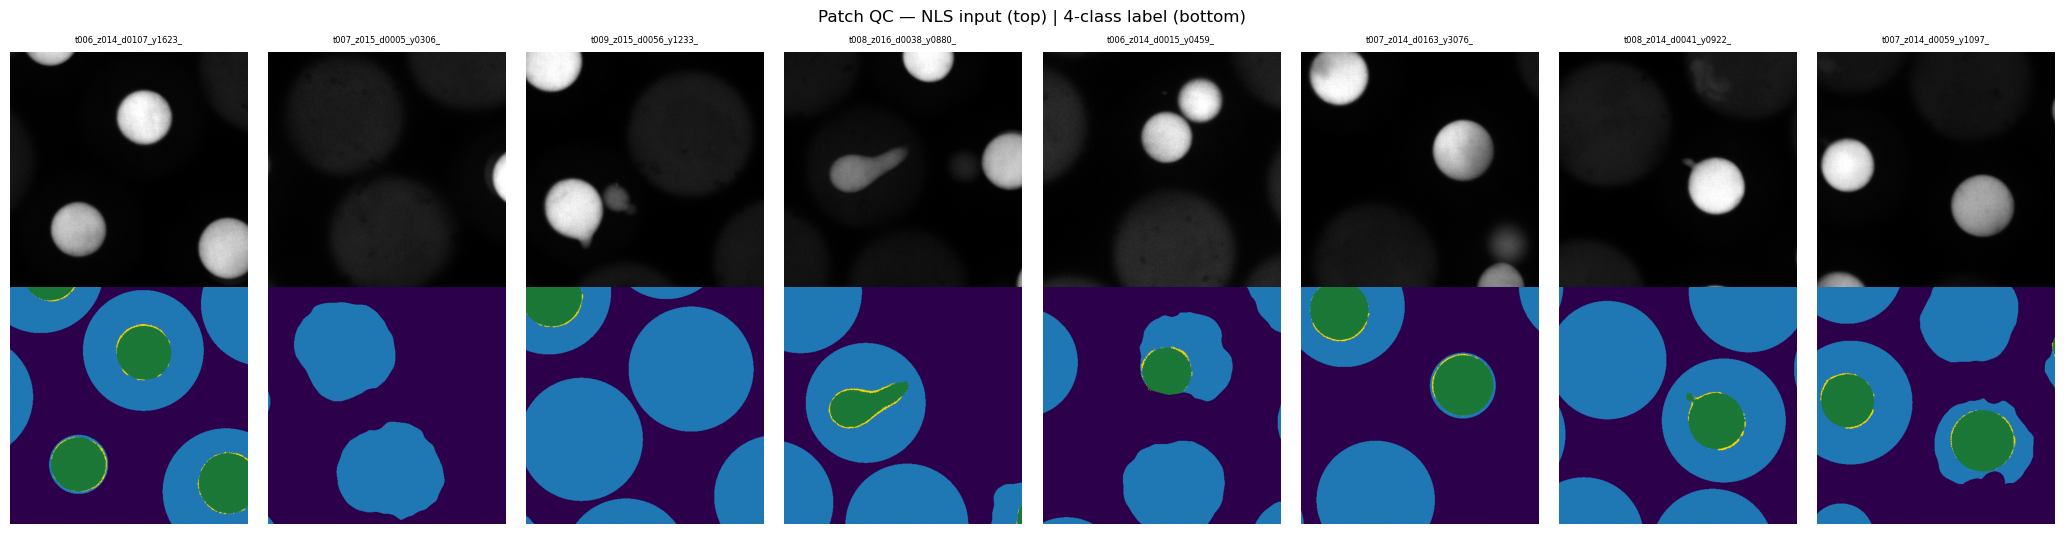

In [25]:
# ============================================================
# 11. Patch QC
# ============================================================
_LABEL_CMAP = ListedColormap(["#2d004b", "#1f78b4", "#ffd700", "#1b7837"])  # bg/drop/npc/nuc

def preview_patches(n=8, cfg=cfg, seed=None):
    img_paths, lab_paths = list_patch_files(cfg)
    if not img_paths:
        print("No patches found. Run build_training_patches_parallel first.")
        return
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(img_paths), size=min(n, len(img_paths)), replace=False)
    fig, ax = plt.subplots(2, len(idx), figsize=(2.6*len(idx), 5.4))
    if len(idx) == 1:
        ax = ax[:, None]
    for j, i in enumerate(idx):
        x = np.load(img_paths[i]); y = np.load(lab_paths[i])
        ax[0, j].imshow(x[..., 0], cmap="gray")            # NLS channel
        ax[0, j].set_title(img_paths[i].name.replace("img_", "")[:22], fontsize=6)
        ax[1, j].imshow(collapse_to_integer_hwc(y), cmap=_LABEL_CMAP, vmin=0, vmax=3)
        ax[0, j].axis("off"); ax[1, j].axis("off")
    plt.suptitle("Patch QC — NLS input (top) | 4-class label (bottom)")
    plt.tight_layout(); plt.show()

preview_patches(8)


## 12. Training — datasets, U-Net, loss

Carried through unchanged from v8.1 (the patch contract is identical, so the
training half does not change). Multi-label sigmoid head; weighted BCE + Dice;
per-class Dice metrics with `val_npc_dice` as the checkpoint monitor.

In [26]:
# ============================================================
# 12a. TF dataset — multi-label sigmoid targets (H, W, 4)
# ============================================================
def augment_pair(image, label):
    n_img_ch = image.shape[-1]
    combined = tf.concat([image, label], axis=-1)
    combined = tf.image.random_flip_left_right(combined)
    combined = tf.image.random_flip_up_down(combined)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    combined = tf.image.rot90(combined, k=k)
    return combined[..., :n_img_ch], combined[..., n_img_ch:]

def load_npy_pair_py(img_path, lab_path):
    if isinstance(img_path, bytes): img_path = img_path.decode('utf-8')
    if isinstance(lab_path, bytes): lab_path = lab_path.decode('utf-8')
    return np.load(img_path).astype('float32'), np.load(lab_path).astype('float32')

def tf_load_npy_pair(img_path, lab_path):
    x, y = tf.numpy_function(load_npy_pair_py, [img_path, lab_path], [tf.float32, tf.float32])
    x.set_shape((cfg.patch_size, cfg.patch_size, cfg.n_channels))
    y.set_shape((cfg.patch_size, cfg.patch_size, cfg.num_classes))
    return x, y

def make_dataset(img_paths, lab_paths, batch_size=None, shuffle=True, augment=False):
    batch_size = batch_size or cfg.batch_size
    ds = tf.data.Dataset.from_tensor_slices((list(map(str, img_paths)), list(map(str, lab_paths))))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths), seed=cfg.seed, reshuffle_each_iteration=True)
    ds = ds.map(tf_load_npy_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def build_train_val_datasets(cfg=cfg):
    img_paths, lab_paths = list_patch_files(cfg)
    if len(img_paths) != len(lab_paths):
        raise ValueError(f"Image/label count mismatch: {len(img_paths)} vs {len(lab_paths)}")
    if not img_paths:
        raise ValueError("No patches found. Run generation first.")
    val_t = list(cfg.val_timepoints) if cfg.val_timepoints is not None else []
    val_t_strs = [f"_t{t:03d}_" for t in val_t]
    train_img, train_lab, val_img, val_lab = [], [], [], []
    for ip, lp in zip(img_paths, lab_paths):
        if any(s in ip.name for s in val_t_strs):
            val_img.append(ip); val_lab.append(lp)
        else:
            train_img.append(ip); train_lab.append(lp)
    if not val_img:
        raise ValueError(f"No patches matched val_timepoints={val_t}.")
    def _census(paths):
        kinds = {"pos": 0, "neg": 0, "cap": 0, "other": 0}
        for p in paths:
            for k in ("pos", "neg", "cap"):
                if f"_{k}_" in p.name:
                    kinds[k] += 1
                    break
            else:
                kinds["other"] += 1
        return kinds

    tr_k, va_k = _census(train_img), _census(val_img)
    print(f"Train patches: {len(train_img)}   {tr_k}")
    print(f"Val   patches: {len(val_img)}   {va_k}")
    n_neg_val = va_k["neg"] + va_k["cap"]
    if n_neg_val:
        print(f"NOTE: {n_neg_val}/{len(val_img)} val patches are negatives. "
              f"Per-sample masked metrics handle this; batch-aggregated Dice "
              f"(the v9 metric) would NOT — that is why Vulcan 1.0's "
              f"val_npc_dice was not comparable to v9's.")
    train_ds = make_dataset(train_img, train_lab, cfg.batch_size, shuffle=True,  augment=cfg.use_augmentation)
    val_ds   = make_dataset(val_img,   val_lab,   cfg.batch_size, shuffle=False, augment=False)
    return train_ds, val_ds, train_img, val_img

train_ds, val_ds, train_img_paths, val_img_paths = build_train_val_datasets(cfg)


Train patches: 3203   {'pos': 1361, 'neg': 1739, 'cap': 103, 'other': 0}
Val   patches: 1584   {'pos': 763, 'neg': 780, 'cap': 41, 'other': 0}
NOTE: 821/1584 val patches are negatives. Per-sample masked metrics handle this; batch-aggregated Dice (the v9 metric) would NOT — that is why Vulcan 1.0's val_npc_dice was not comparable to v9's.


2026-07-28 14:47:43.073398: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0


In [29]:
# ============================================================
# 12b. U-Net (multi-label sigmoid)
# ============================================================
def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding='same')(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    if dropout_rate > 0.0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
    return x

def encoder_block(x, filters, dropout_rate=0.0):
    c = conv_block(x, filters, dropout_rate=dropout_rate)
    return c, layers.MaxPooling2D((2, 2))(c)

def decoder_block(x, skip, filters, dropout_rate=0.0):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    return conv_block(x, filters, dropout_rate=dropout_rate)

def build_unet(input_shape=None, num_classes=None):
    input_shape = input_shape or (cfg.patch_size, cfg.patch_size, cfg.n_channels)
    num_classes = num_classes or cfg.num_classes
    inputs = layers.Input(shape=input_shape)
    c1, p1 = encoder_block(inputs, 32)
    c2, p2 = encoder_block(p1, 64)
    c3, p3 = encoder_block(p2, 128)
    c4, p4 = encoder_block(p3, 256)
    bn = conv_block(p4, 512, dropout_rate=0.5)
    d1 = decoder_block(bn, c4, 256, dropout_rate=0.3)
    d2 = decoder_block(d1, c3, 128, dropout_rate=0.3)
    d3 = decoder_block(d2, c2, 64)
    d4 = decoder_block(d3, c1, 32)
    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(d4)  # independent binary channels
    return models.Model(inputs, outputs, name=cfg.model_name)

model = build_unet(); model.summary()


Model: "Vulcan_1.1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 512, 512, 32)         896       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 512, 512, 32)         128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 512, 512, 32)         0         ['batch_normalization

In [30]:
# ============================================================
# 12c. Loss, metrics, training
# ============================================================
_CLASS_WEIGHTS = tf.constant(list(cfg.loss_class_weights), dtype=tf.float32)


def weighted_binary_dice_loss(y_true, y_pred, smooth=1e-6):
    """Batch-aggregated soft Dice. Left as-is deliberately: on an all-negative
    batch the denominator goes to ~0 and the term stops pushing, so negatives
    train via BCE. Changing the loss and the metrics in the same run would make
    neither attributable."""
    axes = [0, 1, 2]
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)
    dice = (2.0*inter + smooth) / (denom + smooth)
    return 1.0 - tf.reduce_sum(_CLASS_WEIGHTS * dice) / tf.reduce_sum(_CLASS_WEIGHTS)


def weighted_binary_ce_loss(y_true, y_pred):
    eps = 1e-7
    yp = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    bce = -(y_true*tf.math.log(yp) + (1.0-y_true)*tf.math.log(1.0-yp))
    return tf.reduce_mean(bce * _CLASS_WEIGHTS)


def combined_weighted_loss(y_true, y_pred):
    return weighted_binary_ce_loss(y_true, y_pred) + weighted_binary_dice_loss(y_true, y_pred)


# ------------------------------------------------------------------
# Metrics.
#
# v9's _class_dice reduced over the batch axis. Once hard negatives entered the
# dataset that became uninterpretable: a batch whose two patches both have empty
# ground truth returns smooth/smooth = 1.0 for a silent model and ~0.0 for a
# single false-positive pixel, and Keras then means that over batches. Vulcan
# 1.0's val_npc_dice of 0.479 is a blend of true Dice and a bimodal FP penalty,
# and is NOT on the same scale as v9's 0.621.
#
# These are stateful and accumulate over the epoch, so they are independent of
# batch composition, and they separate the two quantities:
#   ClassDice    — mean per-sample Dice over samples that HAVE the class
#   EmptyFPRate  — mean predicted-positive pixel fraction over samples that DO NOT
#
# EmptyFPRate on the nucleus channel is the number this whole revision exists to
# reduce: on a mined cap patch, any nucleus prediction is a false positive by
# construction. Report it against Vulcan 1.0 in the methods paper.
# ------------------------------------------------------------------
_SM = 1e-6


class ClassDice(tf.keras.metrics.Metric):
    def __init__(self, ch, name, **kw):
        super().__init__(name=name, **kw)
        self.ch = ch
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        yt = y_true[..., self.ch]
        yp = tf.cast(y_pred[..., self.ch] > 0.5, tf.float32)
        axes = [1, 2]
        inter = tf.reduce_sum(yt * yp, axis=axes)
        denom = tf.reduce_sum(yt, axis=axes) + tf.reduce_sum(yp, axis=axes)
        dice = (2.0 * inter + _SM) / (denom + _SM)
        has_pos = tf.cast(tf.reduce_sum(yt, axis=axes) > 0, tf.float32)
        self.total.assign_add(tf.reduce_sum(dice * has_pos))
        self.count.assign_add(tf.reduce_sum(has_pos))

    def result(self):
        return tf.math.divide_no_nan(self.total, self.count)

    def reset_state(self):
        self.total.assign(0.0); self.count.assign(0.0)


class EmptyFPRate(tf.keras.metrics.Metric):
    """Predicted-positive pixel fraction on samples with NO ground truth."""
    def __init__(self, ch, name, **kw):
        super().__init__(name=name, **kw)
        self.ch = ch
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        yt = y_true[..., self.ch]
        yp = tf.cast(y_pred[..., self.ch] > 0.5, tf.float32)
        axes = [1, 2]
        is_empty = tf.cast(tf.reduce_sum(yt, axis=axes) <= 0, tf.float32)
        fp_frac = tf.reduce_mean(yp, axis=axes)
        self.total.assign_add(tf.reduce_sum(fp_frac * is_empty))
        self.count.assign_add(tf.reduce_sum(is_empty))

    def result(self):
        return tf.math.divide_no_nan(self.total, self.count)

    def reset_state(self):
        self.total.assign(0.0); self.count.assign(0.0)


class ClassQuality(tf.keras.metrics.Metric):
    """Dice-on-positives minus FP-rate-on-empties, for one class.

    A single scalar suitable for checkpoint selection: rewards recall on real
    nuclei while penalising exactly the cap false positives this revision
    targets. v9 monitored val_npc_dice on all three callbacks, so the saved
    weights were the best NPC model — while nucleus was the actual problem.
    """
    def __init__(self, ch, name, fp_weight=1.0, **kw):
        super().__init__(name=name, **kw)
        self.dice = ClassDice(ch, name=f"_{name}_dice")
        self.fp = EmptyFPRate(ch, name=f"_{name}_fp")
        self.fp_weight = fp_weight

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.dice.update_state(y_true, y_pred)
        self.fp.update_state(y_true, y_pred)

    def result(self):
        return self.dice.result() - self.fp_weight * self.fp.result()

    def reset_state(self):
        self.dice.reset_state(); self.fp.reset_state()


def build_metrics():
    return [
        ClassDice(CLASS_DROPLET, name="droplet_dice"),
        ClassDice(CLASS_NPC,     name="npc_dice"),
        ClassDice(CLASS_NUCLEUS, name="nucleus_dice"),
        EmptyFPRate(CLASS_NPC,     name="npc_fp"),
        EmptyFPRate(CLASS_NUCLEUS, name="nucleus_fp"),
        ClassQuality(CLASS_NUCLEUS, name="nucleus_quality"),
    ]


def compile_and_train(model, train_ds, val_ds, cfg=cfg):
    monitor = cfg.checkpoint_monitor
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.learning_rate),
        loss=combined_weighted_loss,
        metrics=build_metrics())
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(str(cfg.best_model_path), monitor=monitor,
                                           save_best_only=True, mode='max', verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=4,
                                             min_delta=1e-4, mode='max', verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor=monitor, patience=10,
                                         restore_best_weights=True, mode='max', verbose=1),
        tf.keras.callbacks.CSVLogger(str(cfg.qc_dir / f"history_{cfg.model_name}.csv")),
    ]
    print(f"monitoring: {monitor}")
    history = model.fit(train_ds, validation_data=val_ds, epochs=cfg.epochs,
                        callbacks=callbacks)
    model.save(cfg.final_model_path)
    return history


history = compile_and_train(model, train_ds, val_ds, cfg)


monitoring: val_nucleus_quality
Epoch 1/50


2026-07-28 14:52:44.673871: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inVulcan_1.1/spatial_dropout2d/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-07-28 14:52:45.685509: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-07-28 14:52:52.411838: I external/local_xla/xla/service/service.cc:168] XLA service 0x2aac12ecb680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-28 14:52:52.411878: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2026-07-28 14:52:52.420914: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785268372.561059   59544 device_compiler.h:186] Compiled cluster 

1602/1602 [==============================] - ETA: 0s - loss: 1.3585 - droplet_dice: 0.7933 - npc_dice: 0.3623 - nucleus_dice: 0.7417 - npc_fp: 0.0295 - nucleus_fp: 0.0539 - nucleus_quality: 0.6878
Epoch 1: val_nucleus_quality improved from -inf to 0.65998, saving model to /home/tdeibert/Data/Machine_Learning_Dev/Models/Vulcan_1.1_best.keras
1602/1602 [==============================] - 101s 49ms/step - loss: 1.3585 - droplet_dice: 0.7933 - npc_dice: 0.3623 - nucleus_dice: 0.7417 - npc_fp: 0.0295 - nucleus_fp: 0.0539 - nucleus_quality: 0.6878 - val_loss: 1.0977 - val_droplet_dice: 0.8040 - val_npc_dice: 0.5282 - val_nucleus_dice: 0.7014 - val_npc_fp: 0.0055 - val_nucleus_fp: 0.0414 - val_nucleus_quality: 0.6600 - lr: 1.0000e-04
Epoch 2/50
1602/1602 [==============================] - ETA: 0s - loss: 0.9352 - droplet_dice: 0.8220 - npc_dice: 0.5319 - nucleus_dice: 0.7599 - npc_fp: 0.0042 - nucleus_fp: 0.0355 - nucleus_quality: 0.7244
Epoch 2: val_nucleus_quality did not improve from 0.6599

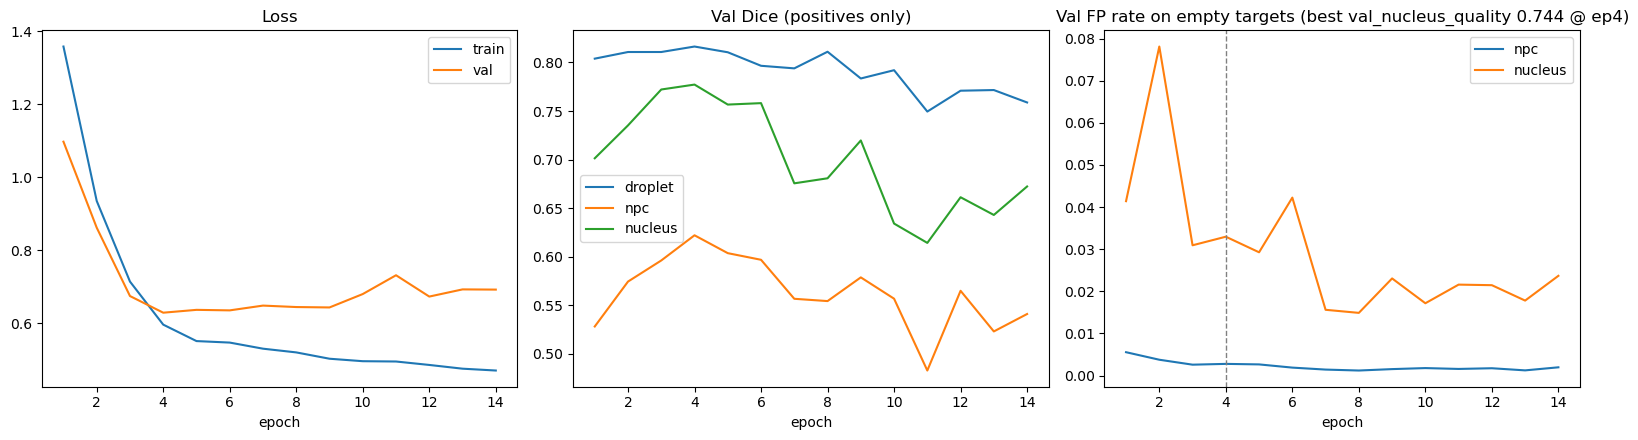

In [31]:
import matplotlib.pyplot as plt

def plot_history(history, cfg=cfg):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(epochs, h['loss'], label='train')
    ax[0].plot(epochs, h['val_loss'], label='val')
    ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()

    for cls in ['droplet_dice', 'npc_dice', 'nucleus_dice']:
        ax[1].plot(epochs, h['val_' + cls], label=cls.replace('_dice', ''))
    ax[1].set_title('Val Dice (positives only)')
    ax[1].set_xlabel('epoch'); ax[1].legend()

    # The panel that matters: FP rate on patches where the class is absent by
    # construction. This is the quantity Vulcan 1.0 could not measure.
    for cls in ['npc_fp', 'nucleus_fp']:
        ax[2].plot(epochs, h['val_' + cls], label=cls.replace('_fp', ''))
    mon = cfg.checkpoint_monitor
    if mon in h:
        best = max(h[mon]); best_ep = h[mon].index(best) + 1
        ax[2].axvline(best_ep, ls='--', c='grey', lw=1)
        ax[2].set_title(f'Val FP rate on empty targets '
                        f'(best {mon} {best:.3f} @ ep{best_ep})')
    else:
        ax[2].set_title('Val FP rate on empty targets')
    ax[2].set_xlabel('epoch'); ax[2].legend()

    plt.tight_layout()
    fig.savefig(cfg.qc_dir / f"history_{cfg.model_name}.png", dpi=150)
    plt.show()

plot_history(history)


In [33]:
# ============================================================
# QC inference — tiled full-frame segmentation on the training image
# Outputs (droplet, NPC, nucleus) probability + binary mask hyperstacks
# ============================================================
from tensorflow.keras import models as _models

# ---- knobs ----
STRIDE        = 384          # tile stride (ps=512 -> 128 px overlap)
BATCH         = 16
THRESH        = 0.5          # per-channel sigmoid threshold for binary masks
PROB_AS_UINT8 = False        # True -> prob scaled 0-255 (file ~13GB vs ~53GB float32)
FG_CLASSES    = [CLASS_DROPLET, CLASS_NPC, CLASS_NUCLEUS]   # output channel order
FG_NAMES      = ["droplet", "npc", "nucleus"]

hs = load_memmap_tiff(cfg.image_file)
n_t, n_z, n_c, H, W = hs.shape
T_RANGE = range(n_t)         # honor "all T"; e.g. range(4,10) to subset
Z_RANGE = range(n_z)         # all Z, including below z_floor: the cap planes
                             # are exactly where the v9 failure showed up, so QC
                             # must cover them even though training did not.

model = _models.load_model(cfg.best_model_path, compile=False)   # forward pass only
ps = cfg.patch_size
_win = (np.hanning(ps)[:, None] * np.hanning(ps)[None, :]).astype(np.float32)[..., None] + 1e-6

def _tile_origins(n, p, s):
    if n <= p:
        return [0]
    xs = list(range(0, n - p + 1, s))
    if xs[-1] != n - p:
        xs.append(n - p)
    return xs

def predict_plane(mem, nuc, npc, t=0):
    """Tiled, Hann-blended (H, W, num_classes) sigmoid probabilities for one plane."""
    acc  = np.zeros((H, W, cfg.num_classes), np.float32)
    wsum = np.zeros((H, W, 1), np.float32)
    origins = [(y, x) for y in _tile_origins(H, ps, STRIDE)
                       for x in _tile_origins(W, ps, STRIDE)]
    for i in range(0, len(origins), BATCH):
        chunk = origins[i:i + BATCH]
        tiles = np.stack([build_input_patch(
            mem[y:y+ps, x:x+ps], nuc[y:y+ps, x:x+ps], npc[y:y+ps, x:x+ps],
            mem_stats=_stats_for(cfg, t, cfg.membrane_channel_idx),
            nuc_stats=_stats_for(cfg, t, cfg.nucleus_channel_idx),
            npc_stats=_stats_for(cfg, t, cfg.npc_channel_idx))
            for (y, x) in chunk])
        preds = model(tf.constant(tiles), training=False).numpy()   # faster than .predict for small batches
        for (y, x), p in zip(chunk, preds):
            acc[y:y+ps, x:x+ps]  += p * _win
            wsum[y:y+ps, x:x+ps] += _win
    return acc / np.maximum(wsum, 1e-6)

# ---- pre-allocate streaming BigTIFF outputs sized to the selected ranges ----
nT, nZ = len(list(T_RANGE)), len(list(Z_RANGE))
prob_dtype = np.uint8 if PROB_AS_UINT8 else np.float32
prob_path  = cfg.qc_dir / f"qc_inference_prob_{cfg.model_name}.tif"
mask_path  = cfg.qc_dir / f"qc_inference_mask_{cfg.model_name}.tif"

gb = nT * nZ * 3 * H * W * (1 if PROB_AS_UINT8 else 4) / 1e9
print(f"Planes: {nT*nZ}  | prob file ~{gb:.1f} GB  | mask file ~{nT*nZ*3*H*W/1e9:.1f} GB")
print(f"Channel order: {FG_NAMES}")

prob_mm = tiff.memmap(str(prob_path), shape=(nT, nZ, 3, H, W), dtype=prob_dtype, bigtiff=True)
mask_mm = tiff.memmap(str(mask_path), shape=(nT, nZ, 3, H, W), dtype=np.uint8,  bigtiff=True)

for ti, t in enumerate(tqdm(list(T_RANGE), desc="timepoints")):
    for zi, z in enumerate(Z_RANGE):
        mem = extract_plane(hs, t, z, cfg.membrane_channel_idx)
        nuc = extract_plane(hs, t, z, cfg.nucleus_channel_idx)
        npc = extract_plane(hs, t, z, cfg.npc_channel_idx)
        prob = predict_plane(mem, nuc, npc)                 # (H, W, 4)
        fg = np.transpose(prob[..., FG_CLASSES], (2, 0, 1)) # (3, H, W) droplet/npc/nucleus
        prob_mm[ti, zi] = (fg * 255).round().astype(np.uint8) if PROB_AS_UINT8 else fg
        mask_mm[ti, zi] = (fg >= THRESH).astype(np.uint8) * 255
    prob_mm.flush(); mask_mm.flush()

prob_mm.flush(); mask_mm.flush()
print(f"\nProbability -> {prob_path}")
print(f"Binary mask -> {mask_path}")
print("Axes: (T, Z, C=3, Y, X). In FIJI open via Bio-Formats, or set dimension order XYCZT.")

Planes: 200  | prob file ~53.5 GB  | mask file ~13.4 GB
Channel order: ['droplet', 'npc', 'nucleus']


timepoints: 100%|██████████| 10/10 [48:55<00:00, 293.52s/it]


Probability -> /home/tdeibert/Data/Machine_Learning_Dev/Outputs/qc_Vulcan_1.1/qc_inference_prob_Vulcan_1.1.tif
Binary mask -> /home/tdeibert/Data/Machine_Learning_Dev/Outputs/qc_Vulcan_1.1/qc_inference_mask_Vulcan_1.1.tif
Axes: (T, Z, C=3, Y, X). In FIJI open via Bio-Formats, or set dimension order XYCZT.


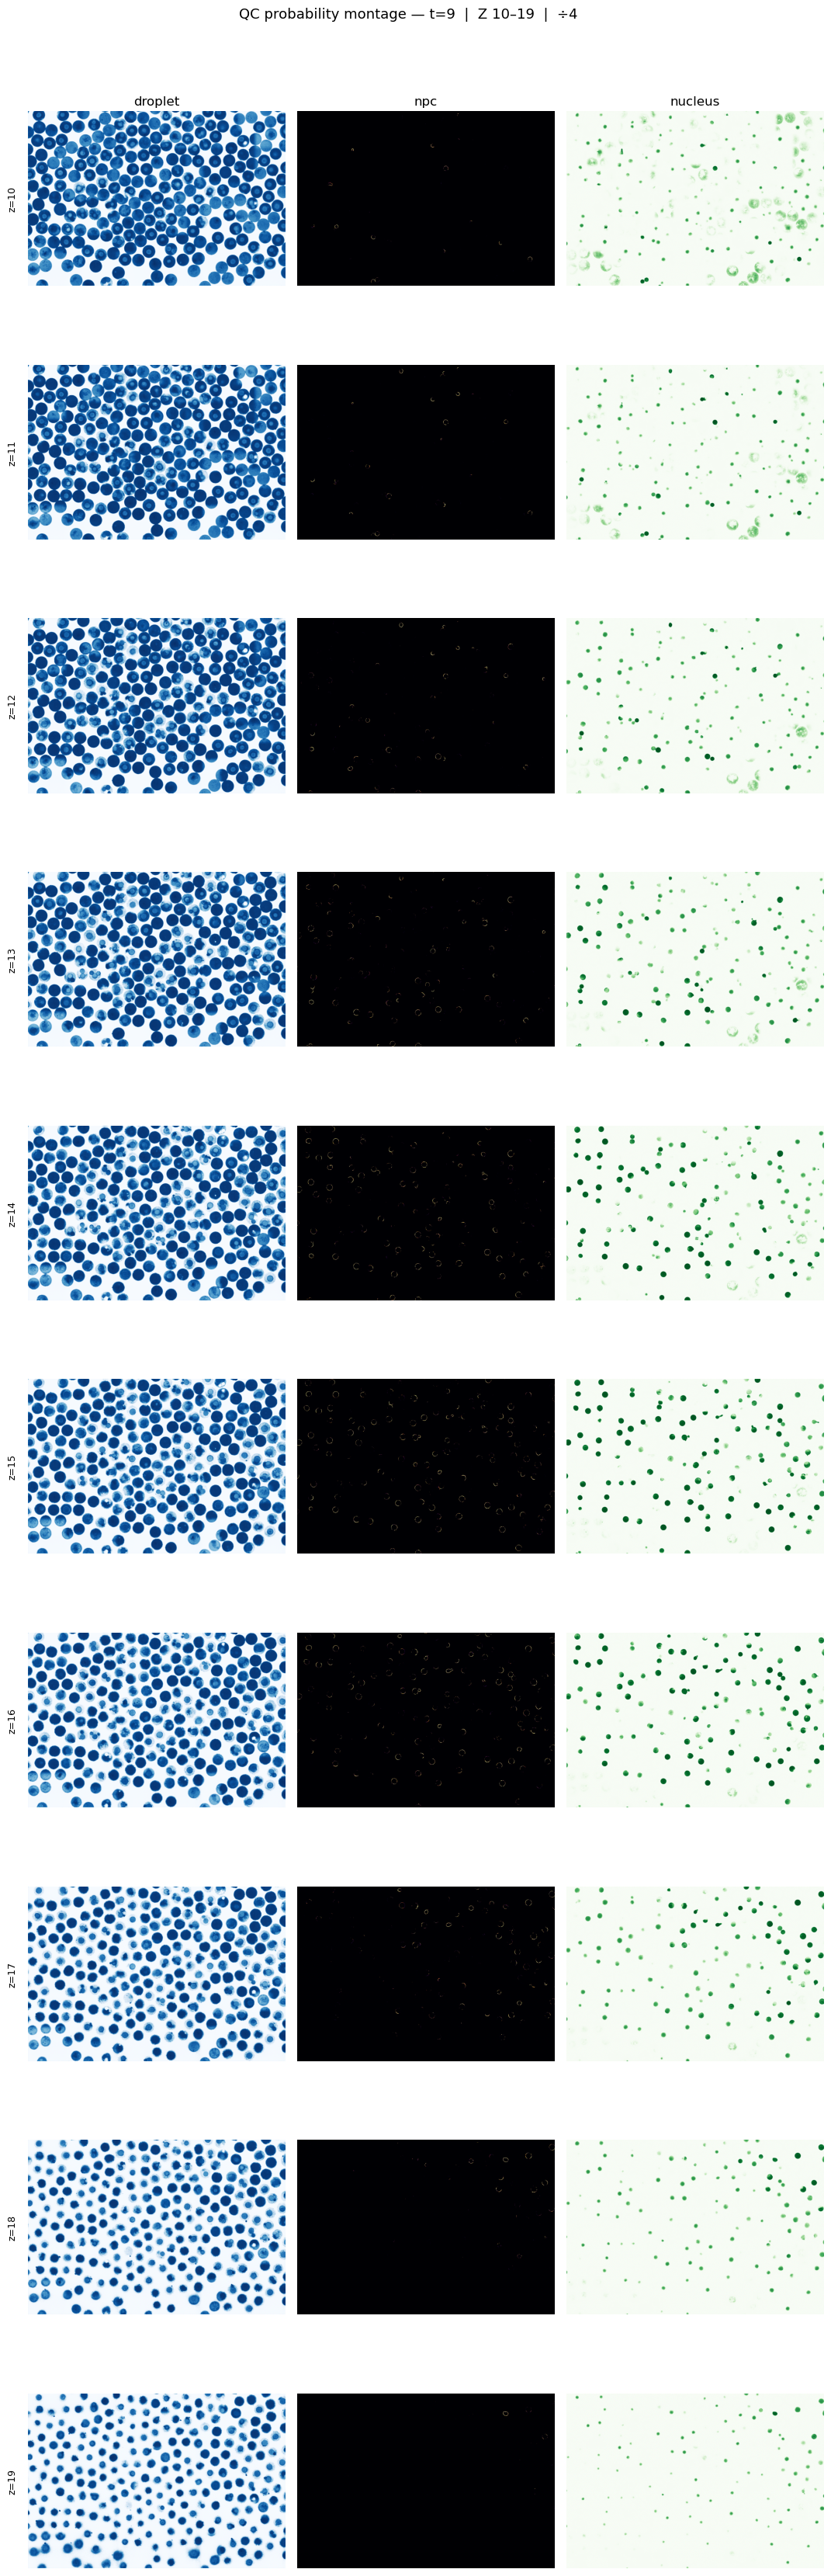

In [35]:
# ============================================================
# QC montage — one timepoint, middle 10 Z, all 3 probability channels
# Rows = Z planes; Cols = [droplet, npc, nucleus]. Reads from the BigTIFF memmap.
# ============================================================
T_SHOW      = 9               # RAW timepoint to display
N_Z_SHOW    = 10                # number of Z planes
Z_CENTER    = cfg.inventory_ref_z   # center of the Z band (equatorial); None -> middle of written stack
DOWNSAMPLE  = 4                 # display decimation (full FOV is 3889x5732; 4 -> ~970x1430)
PROB_IS_UINT8 = False           # must match PROB_AS_UINT8 from the inference cell

prob_path = cfg.qc_dir / f"qc_inference_prob_{cfg.model_name}.tif"
prob_mm = tiff.memmap(str(prob_path))            # (nT, nZ, 3, H, W), read-only view
nT, nZ = prob_mm.shape[0], prob_mm.shape[1]

# resolve the written ranges back to raw indices (must match the inference cell's T_RANGE/Z_RANGE)
T_RANGE = list(range(n_t))                       # <- mirror what you ran
Z_RANGE = list(range(n_z))                       # <- e.g. list(range(cfg.z_floor, n_z)) if you subset
assert len(T_RANGE) == nT and len(Z_RANGE) == nZ, \
    f"Range mismatch: file is {nT}T x {nZ}Z but ranges give {len(T_RANGE)} x {len(Z_RANGE)}. Fix T_RANGE/Z_RANGE."

if T_SHOW not in T_RANGE:
    raise ValueError(f"t={T_SHOW} not in written timepoints {T_RANGE[0]}..{T_RANGE[-1]}")
ti = T_RANGE.index(T_SHOW)

# pick the Z window, centered and clamped to what's on disk
center_raw = Z_CENTER if Z_CENTER is not None else Z_RANGE[nZ // 2]
center_zi  = min(range(nZ), key=lambda i: abs(Z_RANGE[i] - center_raw))
half = N_Z_SHOW // 2
z0 = max(0, min(center_zi - half, nZ - N_Z_SHOW))
z_idx = list(range(z0, min(z0 + N_Z_SHOW, nZ)))

ch_names = ["droplet", "npc", "nucleus"]
ch_cmaps = ["Blues", "inferno", "Greens"]
d = DOWNSAMPLE

fig, ax = plt.subplots(len(z_idx), 3, figsize=(11, 3.4 * len(z_idx)))
if len(z_idx) == 1:
    ax = ax[None, :]
for r, zi in enumerate(z_idx):
    plane = prob_mm[ti, zi]                       # (3, H, W)
    for c in range(3):
        img = plane[c, ::d, ::d].astype(np.float32)
        if PROB_IS_UINT8:
            img /= 255.0
        ax[r, c].imshow(img, cmap=ch_cmaps[c], vmin=0, vmax=1)
        ax[r, c].axis("off")
        if r == 0:
            ax[r, c].set_title(ch_names[c], fontsize=12)
    ax[r, 0].text(-0.04, 0.5, f"z={Z_RANGE[zi]}", transform=ax[r, 0].transAxes,
                  rotation=90, va="center", ha="right", fontsize=9)

plt.suptitle(f"QC probability montage — t={T_SHOW}  |  Z {Z_RANGE[z_idx[0]]}–{Z_RANGE[z_idx[-1]]}  |  ÷{d}",
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0.02, 0, 1, 0.99]); plt.show()

## 13. SLURM / tunnel reference

Standard interactive Ampere allocation:
```
srun --partition=amperenodes --gres=gpu:1 --ntasks=1 --cpus-per-task=8 --mem=32G --time=4:00:00 --pty bash
~/.vscode/cli/code tunnel --name star-forge
```
Patch generation parallelism uses `SLURM_CPUS_PER_TASK` workers. For
fire-and-forget batch generation, wrap `build_training_patches_parallel` in an
`sbatch` script once the methodology is locked.

### Build-order reminder (from the refactor plan)
1. Verify channel order in `build_input_patch` (NLS/NPC/Membrane) — **done, baked in here**.
2. Validate `droplet_geometry` on known droplets/timepoints.
3. Validate the Stage-2 gate against a known empty droplet and a cytoplasmic clump.
4. Small generation run → confirm patches load through `make_dataset`.
5. Carry over remaining QC: early-timepoint NLS, full-FOV consensus, drift.
